# Carbon-Aware ML Training Scheduler

An end-to-end system that forecasts grid carbon intensity and schedules machine learning jobs to minimize emissions under time and resource constraints.

## 1. System Setup and Shared Definitions

Here I define all core components used throughout the notebook, including:
- API utilities
- job schema
- scheduling logic
- evaluation functions

Everything here is reused across both API-based and model-based pipelines.

In [ ]:
###################
# Setup and imports
###################
!pip -q install requests pandas numpy matplotlib

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta, timezone

In [ ]:
# =============
# Configuration
# =============

API_KEY = "vVHdngvhEnmEwm2gX3RP"

# API endpoint
BASE_URL = "https://api.electricitymap.org/v4"

# map Electricity Maps zone identifiers to more readable labels
ZONES = {
    "NYISO": "US-NY-NYIS", # New York grid
    "CAISO": "US-CAL-CISO", # California grid
    "ERCOT": "US-TEX-ERCO", # Texas grid
    "MISO": "US-MIDW-MISO", # Midwest grid
    "ISONE": "US-NE-ISNE", # New England grid
}


In [ ]:
# ============================================================
# Helper to call Electricity Maps API
# ============================================================

def call_electricitymaps(endpoint, params=None):
    """
    Call one Electricity Maps API endpoint and return the parsed JSON response.

    Inputs:
      endpoint: API endpoint path
      params: optional dictionary of query parameters

    Output:
      Parsed API response as a dictionary

    How it works:
      Builds the full URL, sends an authenticated GET request, checks for errors,
      and returns the JSON response if the request succeeds.
    """

    if params is None:
        params = {}

    headers = {
        "auth-token": API_KEY
    }

    url = BASE_URL + endpoint

    # authenticated request with optional query params
    response = requests.get(url, headers=headers, params=params)

    # stop early if the API call fails
    if response.status_code != 200:
        print("Request failed.")
        print("Status code:", response.status_code)
        print("Response text:", response.text)
        response.raise_for_status()

    return response.json()

## Shared Definitions
Here, I define a job class to ensure jobs generated for this study contain the specific properties required to consistently run scheduling. These properties include:  
  - when it arrives (submission_time)
  - when it must finish (deadline)
  - how long it takes (runtime)
  - how much energy it uses (energy)
  - where it is allowed to run (region)

This is an important simplification of how real-world jobs are structured and run.

In [ ]:
"""
Job schema/define a job class:
each job must have specific properties to consistently run scheduling, such as:
  - unique identifer for the job (job_id)
  - when it arrives (submission_time)
  - when it must finish (deadline)
  - the maximum number of hours the scheduler is allowed to delay the job after submission (max_delay_hours)
  - total energy the job is expected to consume in kilowatt-hours (total_energy_kw)
  - the region where the job would normally run under a standard scheduler (default_region)
  - where it is allowed to run (allowed_regions)
"""
from dataclasses import dataclass
from datetime import timedelta

@dataclass
class MLJob:
    job_id: str
    submission_time: pd.Timestamp
    deadline: pd.Timestamp
    max_delay_hours: int
    runtime_hours: int
    total_energy_kwh: float
    default_region: str
    allowed_regions: list

In [ ]:
"""
Function to compute the set of all start times the scheduler is allowed to consider for a job:
essentially, given the job's arrival time, deadline, runtime, and allowed delay, find which hourly start times are feasible

I use this rule:
s ∈ [t0​, min(t0​+M, D−R)]
  - s: a possible start time
  - t_0: job submission time
  - M: maximum delay in hours
  - D: job deadline
  - R: job runtime
means:
a valid start time s must be:
  - no earlier than the submission time t_0
  - no later than whichever is smaller of:
    - latest time allowed by delay t_0 + M
    - latest time allowed by deadline D - R
"""

def get_feasible_start_times(job):
    """
    Return all feasible hourly start times for a job.

    A feasible start time:
    - cannot be before submission_time
    - cannot be later than submission_time + max_delay_hours
    - cannot be so late that the job misses its deadline
    """
    # set lower bound of start time as right when job is submitted
    earliest_start = job.submission_time
    # compute latest time job is allowed to start based only on delay constraint
    latest_start_by_delay = job.submission_time + pd.Timedelta(hours=job.max_delay_hours)
    # compute latest time job can start and finish by deadline
    latest_start_by_deadline = job.deadline - pd.Timedelta(hours=job.runtime_hours)
    # choose earliest of the two upper bounds/what the latest time is it can start the job and still finish it by constraints
    latest_feasible_start = min(latest_start_by_delay, latest_start_by_deadline)

    # handle impossible job inputs
    if latest_feasible_start < earliest_start:
        return []

    # generate hourly candidate start times
    start_times = pd.date_range(
        start=earliest_start,
        end=latest_feasible_start,
        freq="h"
    )

    return list(start_times)


In [ ]:
"""
Get the carbon-intensity rows for a given region and execution window.
Inputs:
  - start_time: candidate start time being evaluated
  - runtime_hours: how long job will run
  - carbon_df: the df containing carbon-intensity time series

Output:
  - filtered dataframe containing the relevant carbon-intensity rows
"""
def get_execution_window(region_name, start_time, runtime_hours, carbon_df):
    # Return the carbon-intensity rows for a given region and execution window.
    end_time = start_time + pd.Timedelta(hours=runtime_hours)

    # filter carbon data to selected region
    df_region = carbon_df[carbon_df["region_name"] == region_name].copy()

    # filter carbon data to execution window
    window = df_region[
        (df_region["datetime"] >= start_time) &
        (df_region["datetime"] < end_time)
    ].copy()

    return window

In [ ]:
# Function to check if we have complete carbon data for the entire duration of the job;
# needed because forecast only goes to 24 hours but possible start times may exceed 24 hours,
# so only use windows where we have carbon data for full window

def has_full_window(region_name, start_time, runtime_hours, carbon_df):
    window = get_execution_window(region_name, start_time, runtime_hours, carbon_df)
    return len(window) == runtime_hours

In [ ]:
"""
Function to compute total predicted emissions for running a job in a region at a given start time.
Use: Emissions = Energy Used x Carbon Intensity, summed for each hour in the window
Returns emissions in gCO2eq.
"""

def calculate_schedule_emissions(job, region_name, start_time, carbon_df):
    # get hourly carbon-intensity rows corresponding to job's execution window
    window = get_execution_window(region_name, start_time, job.runtime_hours, carbon_df)

    if len(window) != job.runtime_hours:
        return None

    # find energy used per hour; simplification note: assuming energy distributed evenly over runtime
    energy_per_hour = job.total_energy_kwh / job.runtime_hours

    # compute emissions per hour and sum
    total_emissions_gco2 = (energy_per_hour * window["carbonIntensity"]).sum()

    return total_emissions_gco2

In [ ]:
# ===================================================================================================
# Carbon-aware scheduler: Find the feasible region and start time with the lowest predicted emissions
# ===================================================================================================

def carbon_aware_schedule(job, carbon_df):
    # get all feasible start times
    feasible_starts = get_feasible_start_times(job)

    # where to store all candidate schedules
    candidate_rows = []

    # loop over all allowed regions and each feasible start time to compute emissions for each candidate
    for region_name in job.allowed_regions:
        for start_time in feasible_starts:
            # verify carbon data exists for full runtime window
            if not has_full_window(region_name, start_time, job.runtime_hours, carbon_df):
                continue
            # compute emissions for candidate
            emissions = calculate_schedule_emissions(job, region_name, start_time, carbon_df)

            if emissions is None:
                continue
            # calculates how long job had to wait before starting to expose tradeoff between lower emissions vs longer wait time
            delay_hours = int((start_time - job.submission_time) / pd.Timedelta(hours=1))
            finish_time = start_time + pd.Timedelta(hours=job.runtime_hours)

            # store candidate schedule's information
            candidate_rows.append({
                "job_id": job.job_id,
                "region_name": region_name,
                "start_time": start_time,
                "finish_time": finish_time,
                "delay_hours": delay_hours,
                "runtime_hours": job.runtime_hours,
                "total_energy_kwh": job.total_energy_kwh,
                "predicted_emissions_gco2": emissions
            })

    # convert candidate list to DataFrame for easier management
    candidates_df = pd.DataFrame(candidate_rows)

    if candidates_df.empty:
        return {
            "best_schedule": None,
            "candidates_df": candidates_df
        }

    # find row with minimum predicted emissions
    best_idx = candidates_df["predicted_emissions_gco2"].idxmin()
    # extract best row as a dict so easy to look up
    best_schedule = candidates_df.loc[best_idx].to_dict()

    # return best schedule and candidate table sorted by next lowest-emissions
    return {
        "best_schedule": best_schedule,
        "candidates_df": candidates_df.sort_values("predicted_emissions_gco2").reset_index(drop=True)
    }

In [ ]:
# ====================
# Baseline scheduler
# ====================

def baseline_schedule(job, carbon_df):
    """
    Runs the job immediately in its default region without any optimization.
    This serves as a simple baseline to compare against carbon-aware scheduling.

    Inputs:
        - job: job object with submission time, runtime, energy, and region info
        - carbon_df: DataFrame with carbon intensity forecasts by region and time

    Outputs:
        - dict with schedule details and predicted emissions
        - None if schedule cannot be evaluated
    """

    # Start immediately at submission time
    start_time = job.submission_time

    # Use the job’s default region (no optimization)
    region_name = job.default_region

    # Check if we have full carbon data for the entire runtime window
    if not has_full_window(region_name, start_time, job.runtime_hours, carbon_df):
        return None

    # Estimate emissions for running now in this region
    emissions = calculate_schedule_emissions(job, region_name, start_time, carbon_df)

    # If emissions couldn’t be computed, skip this schedule
    if emissions is None:
        return None

    # Return full schedule + emissions info
    return {
        "job_id": job.job_id,  # identify the job
        "region_name": region_name,  # where it runs
        "start_time": start_time,  # when it starts
        "finish_time": start_time + pd.Timedelta(hours=job.runtime_hours),  # when it ends
        "delay_hours": 0,  # no waiting in baseline
        "runtime_hours": job.runtime_hours,  # duration
        "total_energy_kwh": job.total_energy_kwh,  # energy use
        "predicted_emissions_gco2": emissions  # total emissions
    }

In [ ]:
# ============================================================
# Comparison summary
# ============================================================

def compare_schedulers(baseline_result, carbon_aware_result):
    """
    Compares baseline vs carbon-aware schedules to quantify emissions savings
    and any added delay from using the cleaner option.

    Inputs:
        - baseline_result: dict from baseline scheduler
        - carbon_aware_result: dict from carbon-aware scheduler

    Outputs:
        - dict with emissions comparison, savings, delay difference, and key metadata
        - None if either result is missing
    """

    # If either schedule failed, we can’t compare
    if baseline_result is None or carbon_aware_result is None:
        return None

    # Extract emissions from both schedules
    baseline_emissions = baseline_result["predicted_emissions_gco2"]
    carbon_aware_emissions = carbon_aware_result["predicted_emissions_gco2"]

    # Compute absolute emissions savings (how much CO2 we avoided)
    absolute_savings = baseline_emissions - carbon_aware_emissions

    # Compute percent savings relative to baseline (avoid divide-by-zero)
    percent_savings = (absolute_savings / baseline_emissions) * 100 if baseline_emissions > 0 else 0

    # Compute how much extra delay the carbon-aware option introduced
    added_delay = carbon_aware_result["delay_hours"] - baseline_result["delay_hours"]

    # Return all comparison metrics + key schedule info
    return {
        "baseline_emissions_gco2": baseline_emissions,  # baseline emissions
        "carbon_aware_emissions_gco2": carbon_aware_emissions,  # optimized emissions
        "absolute_savings_gco2": absolute_savings,  # CO2 reduction
        "percent_savings": percent_savings,  # % reduction
        "added_delay_hours": added_delay,  # extra wait time
        "baseline_region": baseline_result["region_name"],  # baseline region
        "carbon_aware_region": carbon_aware_result["region_name"],  # optimized region
        "baseline_start_time": baseline_result["start_time"],  # baseline start
        "carbon_aware_start_time": carbon_aware_result["start_time"]  # optimized start
    }

In [ ]:
# =====================================
# Function to help with results display
# =====================================

def display_schedule_result(title, result_dict):
    print("=" * 60)
    print(title)
    print("=" * 60)
    if result_dict is None:
        print("No feasible result.")
        return

    for key, value in result_dict.items():
        print(f"{key}: {value}")
    print()


In [ ]:
# ===============================
# Create batch of simulation jobs
# ===============================

import random

def generate_synthetic_jobs(
    n_jobs=25,
    submission_start=None,
    submission_end=None,
    region_names=None,
    seed=42
):
    """
    Generates a batch of synthetic ML jobs with varied runtimes, energy use,
    deadlines, and flexibility to simulate realistic scheduling scenarios.

    Inputs:
        - n_jobs: number of jobs to generate
        - submission_start: start time for possible job submissions
        - submission_end: end time for possible job submissions
        - region_names: list of regions jobs can run in
        - seed: random seed for reproducibility

    Outputs:
        - list of MLJob objects with randomized but realistic properties
    """

    # Set seeds so results are reproducible
    random.seed(seed)
    np.random.seed(seed)

    # Default submission window starts now (rounded to hour)
    if submission_start is None:
        submission_start = pd.Timestamp.utcnow().floor("h")

    # Default submission window spans next 12 hours
    if submission_end is None:
        submission_end = submission_start + pd.Timedelta(hours=12)

    # Default set of regions if none provided
    if region_names is None:
        region_names = ["NYISO", "CAISO", "ERCOT", "MISO", "ISONE"]

    # Create all possible submission timestamps (hourly)
    submission_times = pd.date_range(
        start=submission_start,
        end=submission_end,
        freq="h"
    )

    # Store all generated jobs
    jobs = []

    # Generate each job one by one
    for i in range(n_jobs):

        # Randomly pick a submission time from the window
        submission_time = random.choice(list(submission_times))

        # Pick runtime from a mix of short to long jobs
        runtime_hours = random.choice([2, 3, 4, 6, 8])

        # Estimate energy use based on runtime + some randomness
        total_energy_kwh = round(runtime_hours * random.uniform(1.5, 4.0), 2)

        # Assign how long the job is willing to wait before starting
        max_delay_hours = random.choice([0, 2, 4, 6, 8, 12])

        # Add slack to ensure deadline is feasible
        slack_hours = random.choice([2, 4, 6, 8, 12, 18, 24])
        deadline = submission_time + pd.Timedelta(hours=runtime_hours + slack_hours)

        # Pick a default region for baseline scheduling
        default_region = random.choice(region_names)

        # Create and store the job object
        jobs.append(
            MLJob(
                job_id=f"job_{i+1:03d}",  # unique ID like job_001
                submission_time=submission_time,  # when job arrives
                deadline=deadline,  # latest allowed finish
                max_delay_hours=max_delay_hours,  # how long it can wait
                runtime_hours=runtime_hours,  # how long it runs
                total_energy_kwh=total_energy_kwh,  # energy demand
                default_region=default_region,  # baseline region
                allowed_regions=region_names  # all regions allowed
            )
        )

    # Return full list of generated jobs
    return jobs

In [ ]:
#####################################
# Run both schedulers on all jobs
#####################################


def run_scheduler_experiment(jobs, carbon_df):
    """
    Runs both the baseline and carbon-aware schedulers across a batch of jobs
    and collects their results into one comparison table.

    Inputs:
        - jobs: list of MLJob objects to schedule
        - carbon_df: DataFrame with carbon intensity forecasts by region and time

    Outputs:
        - DataFrame with one row per job containing scheduler outputs and comparison metrics
    """
    # Store one result row per job
    results = []

    # Process each job one at a time
    for job in jobs:

        # Run the baseline scheduler for this job
        baseline_result = baseline_schedule(job, carbon_df)

        # Run the carbon-aware scheduler for this job
        carbon_result_obj = carbon_aware_schedule(job, carbon_df)

        # Pull out just the best carbon-aware schedule
        carbon_best = carbon_result_obj["best_schedule"]

        # Start building the row with core job info
        row = {
            "job_id": job.job_id,
            "submission_time": job.submission_time,
            "deadline": job.deadline,
            "max_delay_hours": job.max_delay_hours,
            "runtime_hours": job.runtime_hours,
            "total_energy_kwh": job.total_energy_kwh,
            "default_region": job.default_region
        }

        # Add baseline scheduler results if they exist
        if baseline_result is not None:
            row.update({
                "baseline_region": baseline_result["region_name"],
                "baseline_start_time": baseline_result["start_time"],
                "baseline_finish_time": baseline_result["finish_time"],
                "baseline_delay_hours": baseline_result["delay_hours"],
                "baseline_emissions_gco2": baseline_result["predicted_emissions_gco2"]
            })
        else:
            # Fill with None if baseline couldn't be evaluated
            row.update({
                "baseline_region": None,
                "baseline_start_time": None,
                "baseline_finish_time": None,
                "baseline_delay_hours": None,
                "baseline_emissions_gco2": None
            })

        # Add carbon-aware results if a best schedule was found
        if carbon_best is not None:
            row.update({
                "carbon_region": carbon_best["region_name"],
                "carbon_start_time": carbon_best["start_time"],
                "carbon_finish_time": carbon_best["finish_time"],
                "carbon_delay_hours": carbon_best["delay_hours"],
                "carbon_emissions_gco2": carbon_best["predicted_emissions_gco2"]
            })
        else:
            # Fill with None if no valid carbon-aware schedule was found
            row.update({
                "carbon_region": None,
                "carbon_start_time": None,
                "carbon_finish_time": None,
                "carbon_delay_hours": None,
                "carbon_emissions_gco2": None
            })

        # Compute side-by-side comparison metrics if both schedules exist
        if baseline_result is not None and carbon_best is not None:

            # Compute raw emissions savings from optimization
            absolute_savings = baseline_result["predicted_emissions_gco2"] - carbon_best["predicted_emissions_gco2"]

            # Compute percent savings relative to baseline
            percent_savings = (absolute_savings / baseline_result["predicted_emissions_gco2"]) * 100 if baseline_result["predicted_emissions_gco2"] > 0 else 0

            # Add comparison metrics and change flags
            row.update({
                "absolute_savings_gco2": absolute_savings,
                "percent_savings": percent_savings,
                "extra_delay_hours": carbon_best["delay_hours"] - baseline_result["delay_hours"],
                "changed_region": carbon_best["region_name"] != baseline_result["region_name"],
                "changed_start_time": carbon_best["start_time"] != baseline_result["start_time"]
            })
        else:
            # Fill with None if comparison could not be made
            row.update({
                "absolute_savings_gco2": None,
                "percent_savings": None,
                "extra_delay_hours": None,
                "changed_region": None,
                "changed_start_time": None
            })

        # Save this job’s full result row
        results.append(row)

    # Return all job results as one DataFrame
    return pd.DataFrame(results)

In [ ]:
# ============================================================
# Experiment summary
# ============================================================

def summarize_experiment(results_df):
    """
    Compute aggregate statistics from the scheduler experiment.
    """
    valid = results_df.dropna(subset=["baseline_emissions_gco2", "carbon_emissions_gco2"]).copy()

    if valid.empty:
        return None

    summary = {
        "num_jobs_evaluated": len(valid),
        "total_baseline_emissions_gco2": valid["baseline_emissions_gco2"].sum(),
        "total_carbon_aware_emissions_gco2": valid["carbon_emissions_gco2"].sum(),
        "total_absolute_savings_gco2": valid["absolute_savings_gco2"].sum(),
        "average_percent_savings": valid["percent_savings"].mean(),
        "average_extra_delay_hours": valid["extra_delay_hours"].mean(),
        "median_extra_delay_hours": valid["extra_delay_hours"].median(),
        "jobs_with_region_change_pct": valid["changed_region"].mean() * 100,
        "jobs_with_start_change_pct": valid["changed_start_time"].mean() * 100
    }

    return summary



## API-Based Forecast Pipeline



This section retrieves carbon intensity forecasts directly from Electricity Maps.

These forecasts serve as:
- a realistic baseline
- a comparison point against our custom ML forecasting model, which will come later

In [ ]:
# =======================================
# Function to retrieve carbon forecast
# =======================================

def get_carbon_forecast(zone, emission_factor_type="lifecycle", temporal_granularity="hourly"):
    """
    Retrieve forecasted carbon intensity data for one Electricity Maps zone.

    Inputs:
      zone: Electricity Maps zone code
      emission_factor_type: carbon accounting method used by the API
      temporal_granularity: forecast resolution requested from the API

    Output:
      DataFrame with datetime and carbonIntensity columns

    How it works:
      Calls the Electricity Maps forecast endpoint, converts the returned forecast
      records into a DataFrame, parses timestamps as UTC datetimes, and sorts the
      result chronologically.
    """

    params = {
        "zone": zone,
        "emissionFactorType": emission_factor_type,
        "temporalGranularity": temporal_granularity
    }

    data = call_electricitymaps("/carbon-intensity/forecast", params=params)

    # forecast endpoint returns rows under the "forecast" key
    rows = data["forecast"]

    df = pd.DataFrame(rows)

    # keep only columns used later in the scheduler
    df = df[["datetime", "carbonIntensity"]].copy()

    # API timestamps are UTC
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)

    # keep forecast in time order
    df = df.sort_values("datetime").reset_index(drop=True)

    return df

In [ ]:
# ============================================================
# Test a single zone
# ============================================================

test_zone_name = "ISONE"
test_zone = ZONES[test_zone_name]

forecast_df = get_carbon_forecast(test_zone)

print(forecast_df.head())
print()
print(f"Rows returned: {len(forecast_df)}")
print(f"Columns: {list(forecast_df.columns)}")

                   datetime  carbonIntensity
0 2026-04-20 00:00:00+00:00              230
1 2026-04-20 01:00:00+00:00              209
2 2026-04-20 02:00:00+00:00              316
3 2026-04-20 03:00:00+00:00              259
4 2026-04-20 04:00:00+00:00              264

Rows returned: 25
Columns: ['datetime', 'carbonIntensity']


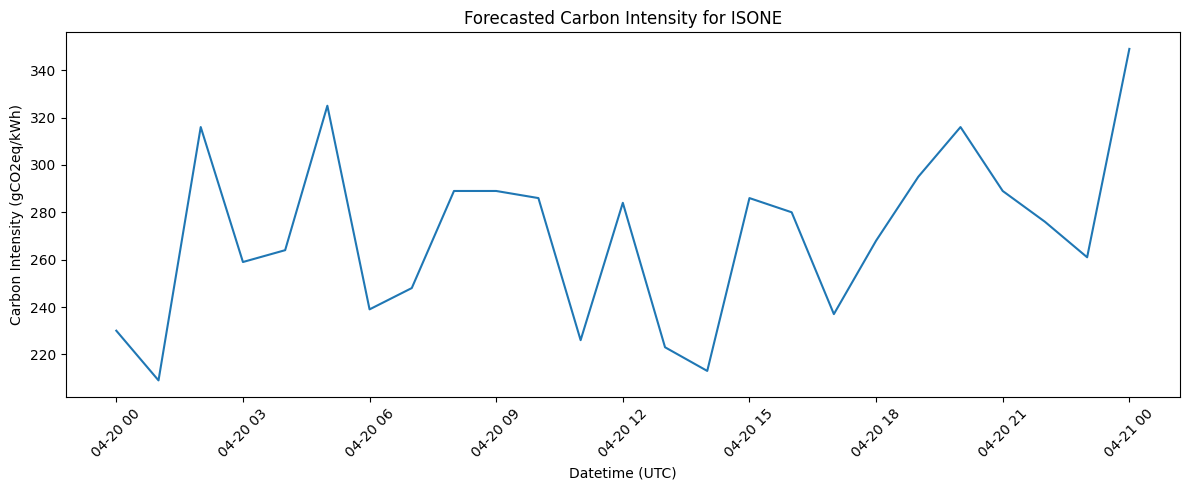

In [ ]:
# ============================================================
# Plot one forecast
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(forecast_df["datetime"], forecast_df["carbonIntensity"])
plt.title(f"Forecasted Carbon Intensity for {test_zone_name}")
plt.xlabel("Datetime (UTC)")
plt.ylabel("Carbon Intensity (gCO2eq/kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insights from ISONE Carbon Intensity Forecast

- **Significant intraday variability**
  - Carbon intensity fluctuates widely hour-to-hour (~210–350 gCO₂/kWh)
  - Timing of workloads meaningfully impacts emissions

- **Identifiable low-carbon windows**
  - Clear dips (early morning, midday) represent optimal execution times
  - Scheduler can reduce emissions by shifting jobs into these periods

- **High-carbon peak periods**
  - Noticeable spikes (early morning, evening, end-of-day)
  - Avoiding these windows can prevent disproportionately high emissions

- **End-of-horizon spike**
  - Sharp increase at final forecast point
  - Suggests either demand surge or forecast uncertainty; avoid late scheduling

- **Daily cyclical pattern**
  - Repeating rise-and-fall behavior across the day
  - Confirms usefulness of time-based features (hour, lag_24, cyclical encoding)

- **Presence of short-term noise**
  - Some irregular hour-to-hour jumps
  - Justifies use of rolling averages and robust forecasting

- **Overall takeaway**
  - Carbon intensity is highly time-dependent with exploitable structure
  - Validates carbon-aware scheduling as an effective emissions reduction strategy

In [ ]:
# ============================================================
# Retrieve forecasts for all zones
# ============================================================

"""
Fetches carbon intensity forecasts for all regions defined in ZONES
by calling the API for each one, then combines everything into one DataFrame.

Inputs:
    - ZONES: dict mapping region_name -> Electricity Maps zone_id

Outputs:
    - carbon_forecast_api_df: combined DataFrame with all regions' forecasts
    - prints success/failure logs and basic preview info
"""

# Store each region’s forecast DataFrame
all_forecasts = []

# Loop through each region and its corresponding API zone ID
for region_name, zone_id in ZONES.items():
    try:
        # Fetch forecast data for this zone
        df_region = get_carbon_forecast(zone_id)

        # Add a readable region name (since API uses zone IDs)
        df_region["region_name"] = region_name

        # Save this region’s data
        all_forecasts.append(df_region)

        # Log success and number of rows retrieved
        print(f"Success: {region_name} -> {len(df_region)} rows")

    except Exception as e:
        # If anything fails, log the region and error
        print(f"Failed: {region_name}")
        print(e)

# Combine all region DataFrames into one big table
carbon_forecast_api_df = pd.concat(all_forecasts, ignore_index=True)

# Print a small preview of the combined data
print()
print(carbon_forecast_api_df.head())

# Print count of rows per region to verify coverage
print()
print(carbon_forecast_api_df["region_name"].value_counts())

Success: NYISO -> 25 rows
Success: CAISO -> 25 rows
Success: ERCOT -> 25 rows
Success: MISO -> 25 rows
Success: ISONE -> 25 rows

                   datetime  carbonIntensity region_name
0 2026-04-20 00:00:00+00:00              248       NYISO
1 2026-04-20 01:00:00+00:00              214       NYISO
2 2026-04-20 02:00:00+00:00              313       NYISO
3 2026-04-20 03:00:00+00:00              260       NYISO
4 2026-04-20 04:00:00+00:00              273       NYISO

region_name
NYISO    25
CAISO    25
ERCOT    25
MISO     25
ISONE    25
Name: count, dtype: int64


### 2.1 API Forecast Visualization

visualize carbon intensity forecasts across all regions to understand temporal and geographic variation in grid cleanliness

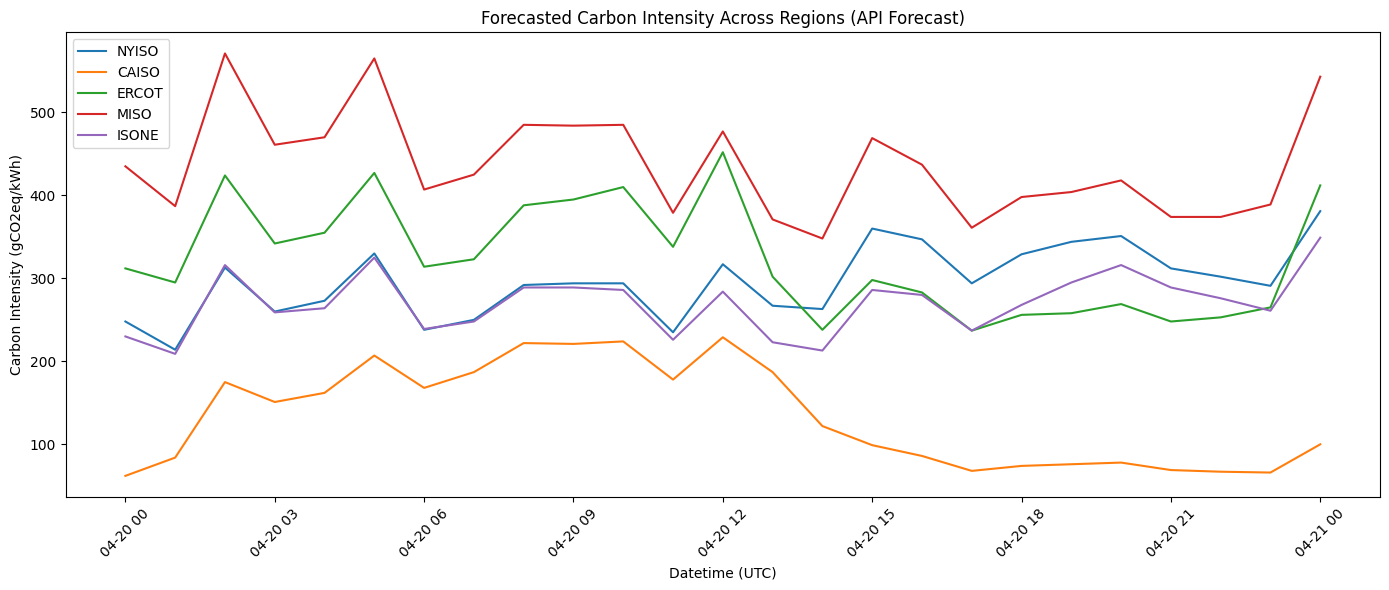

In [ ]:
# ============================================================
# Plot of all regions
# ============================================================

plt.figure(figsize=(14, 6))

for region_name in carbon_forecast_api_df["region_name"].unique():
    df_region = carbon_forecast_api_df[carbon_forecast_api_df["region_name"] == region_name]
    plt.plot(df_region["datetime"], df_region["carbonIntensity"], label=region_name)

plt.title("Forecasted Carbon Intensity Across Regions (API Forecast)")
plt.xlabel("Datetime (UTC)")
plt.ylabel("Carbon Intensity (gCO2eq/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Key Insights from Cross-Region Carbon Intensity Forecast (API)

- **Large variation across regions**
  - CAISO consistently lowest (~60–220), MISO highest (~350–560), others in between
  - Where you run jobs matters just as much as when

- **CAISO as a consistently low-carbon region**
  - Significantly lower than all other regions throughout the day
  - will likely be a strong candidate for preferred scheduling region whenever available

- **MISO is consistently high-carbon**
  - Highest emissions across nearly all time points

- **Moderate regions with variability (NYISO, ISONE, ERCOT)**
  - Mid-range emissions with noticeable fluctuations

- **Cross-region overlap windows**
  - Some times where regions converge or cross
  - → Scheduler can exploit both time and location for optimal decisions

- **Shared temporal patterns across regions**
  - Many regions rise/fall around similar times (likely driven by demand cycles)
  - Validates use of time-based features across all regions

- **Divergence in magnitude despite similar patterns**
  - Regions follow similar shapes but at different intensity levels
  - Reinforces importance of region-specific modeling

- **End-of-horizon increases across multiple regions**
  - Several regions spike toward the end
  - Suggests broader system-wide demand or forecast uncertainty

## 3. Model-Based Carbon Forecast Pipeline

Here I build my own forecasting model using historical carbon intensity data

Steps:
1. Download historical data
2. Engineer time-series features
3. Train forecasting models
4. Generate future carbon intensity predictions

In [ ]:
# ==================================
# Historical carbon data retrieval
# ==================================

def get_carbon_history_chunk(
    zone,
    start_datetime,
    end_datetime,
    emission_factor_type="lifecycle",
    temporal_granularity="hourly"
):
    """
    Retrieve historical carbon intensity data for one API-safe time range.

    Inputs:
      zone: Electricity Maps zone code
      start_datetime: chunk start time as an ISO datetime string
      end_datetime: chunk end time as an ISO datetime string
      emission_factor_type: carbon accounting method used by the API
      temporal_granularity: time resolution requested from the API

    Output:
      DataFrame with historical carbon intensity records for one chunk

    How it works:
      Calls the Electricity Maps past-range endpoint, converts the returned
      history records into a DataFrame, parses timestamps as UTC datetimes,
      keeps the useful columns, and sorts the chunk by time.
    """

    params = {
        "zone": zone,
        "start": start_datetime,
        "end": end_datetime,
        "emissionFactorType": emission_factor_type,
        "temporalGranularity": temporal_granularity
    }

    data = call_electricitymaps("/carbon-intensity/past-range", params=params)

    # past-range endpoint returns rows under the "history" key
    rows = data["history"]

    df = pd.DataFrame(rows)

    # API timestamps are UTC
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)

    # keep only fields used later in modeling/analysis
    keep_cols = [
        "datetime",
        "zone",
        "carbonIntensity",
        "isEstimated",
        "estimationMethod"
    ]

    df = df[keep_cols].copy()

    # keep chunk in time order
    df = df.sort_values("datetime").reset_index(drop=True)

    return df


def get_carbon_history(
    zone,
    start_datetime,
    end_datetime,
    emission_factor_type="lifecycle",
    temporal_granularity="hourly",
    chunk_days=10
):
    """
    Retrieve historical carbon intensity over a longer date range.

    Inputs:
      zone: Electricity Maps zone code
      start_datetime: full start time as an ISO datetime string
      end_datetime: full end time as an ISO datetime string
      emission_factor_type: carbon accounting method used by the API
      temporal_granularity: time resolution requested from the API
      chunk_days: number of days requested per API call

    Output:
      DataFrame with the full historical carbon intensity time series

    How it works:
      Splits the full date range into smaller API-safe chunks, downloads each
      chunk with get_carbon_history_chunk(), combines the chunks, removes
      duplicate boundary timestamps, and sorts the full result by time.
    """

    start_ts = pd.to_datetime(start_datetime, utc=True)
    end_ts = pd.to_datetime(end_datetime, utc=True)

    all_chunks = []
    current_start = start_ts

    while current_start < end_ts:
        # respect API request size limit
        current_end = min(current_start + pd.Timedelta(days=chunk_days), end_ts)

        print(
            f"Downloading {zone}: "
            f"{current_start.strftime('%Y-%m-%d %H:%M')} "
            f"to {current_end.strftime('%Y-%m-%d %H:%M')}"
        )

        chunk_df = get_carbon_history_chunk(
            zone=zone,
            start_datetime=current_start.strftime("%Y-%m-%dT%H:%M:%SZ"),
            end_datetime=current_end.strftime("%Y-%m-%dT%H:%M:%SZ"),
            emission_factor_type=emission_factor_type,
            temporal_granularity=temporal_granularity
        )

        all_chunks.append(chunk_df)

        # move to next time window
        current_start = current_end

    if not all_chunks:
        return pd.DataFrame(columns=[
            "datetime",
            "zone",
            "carbonIntensity",
            "isEstimated",
            "estimationMethod"
        ])

    full_df = pd.concat(all_chunks, ignore_index=True)

    # protect against duplicate rows at chunk boundaries
    full_df = (
        full_df
        .drop_duplicates(subset=["datetime"])
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    return full_df

In [ ]:
# ============================================================
# Training window configuration: last 90 days
# ============================================================

"""
Defines the historical date range we want to pull for model training.
Here, we use the last 90 days of hourly carbon data as the training window.

Inputs:
    - TRAINING_DAYS: number of past days to include in the training history

Outputs:
    - history_start: UTC timestamp for training window start
    - history_end: UTC timestamp for training window end
    - history_start_str / history_end_str: ISO strings for API requests
"""

# Set how many days of historical data we want for training
TRAINING_DAYS = 90

# Set the training window end to the current hour in UTC
# This handles whether utcnow() came in naive or timezone-aware
history_end = pd.Timestamp.utcnow().floor("h").tz_localize("UTC") if pd.Timestamp.utcnow().tzinfo is None else pd.Timestamp.utcnow().floor("h")

# Set the training window start by going 90 days back from the end
history_start = history_end - pd.Timedelta(days=TRAINING_DAYS)

# Convert start time to ISO string format for API calls
history_start_str = history_start.strftime("%Y-%m-%dT%H:%M:%SZ")

# Convert end time to ISO string format for API calls
history_end_str = history_end.strftime("%Y-%m-%dT%H:%M:%SZ")

# Print the final training window so we can verify it
print("History start:", history_start_str)
print("History end:", history_end_str)

History start: 2026-01-20T00:00:00Z
History end: 2026-04-20T00:00:00Z


### 3.1 Historical Data Collection

We retrieve historical carbon intensity data for each region using chunked API calls due to request limits.

In [ ]:
# ============================================================
# Download historical carbon intensity for all zones
# ============================================================

"""
Downloads historical carbon intensity data for all regions in ZONES
over the configured training window, using chunked API requests,
then combines everything into one clean dataset for modeling.

Inputs:
    - ZONES: dict mapping region_name -> Electricity Maps zone_id
    - history_start_str / history_end_str: ISO strings defining training window

Outputs:
    - carbon_history_df: combined DataFrame with all regions' historical data
    - prints success/failure logs and basic dataset checks
"""

# Store each region's historical DataFrame before combining
all_history = []

# Loop through each region and its corresponding API zone ID
for region_name, zone_id in ZONES.items():
    try:
        # Download full historical range for this region (handled in chunks internally)
        df_region = get_carbon_history(
            zone=zone_id,
            start_datetime=history_start_str,
            end_datetime=history_end_str,
            chunk_days=10  # respect API limit per request
        )

        # Add readable region name (since API uses zone IDs)
        df_region["region_name"] = region_name

        # Save this region's data
        all_history.append(df_region)

        # Log success and how many rows we got
        print(f"Success: {region_name} -> {len(df_region)} rows")
        print("-" * 60)

    except Exception as e:
        # Log failures so we know which regions didn't load
        print(f"Failed: {region_name}")
        print(e)
        print("-" * 60)

# If nothing was downloaded, fail early instead of continuing with empty data
if len(all_history) == 0:
    raise ValueError("No historical data was downloaded for any region.")

# Combine all regional DataFrames into one dataset
carbon_history_df = pd.concat(all_history, ignore_index=True)

# Preview the first few rows to sanity-check structure
print()
print(carbon_history_df.head())

# Show row counts per region to verify coverage balance
print()
print(carbon_history_df.groupby("region_name").size())

Success: NYISO -> 2160 rows
------------------------------------------------------------
Success: CAISO -> 2160 rows
------------------------------------------------------------
Success: ERCOT -> 2160 rows
------------------------------------------------------------
Success: MISO -> 2160 rows
------------------------------------------------------------
Success: ISONE -> 2160 rows
------------------------------------------------------------

                   datetime        zone  carbonIntensity  isEstimated  \
0 2026-01-20 00:00:00+00:00  US-NY-NYIS              271         True   
1 2026-01-20 01:00:00+00:00  US-NY-NYIS              234         True   
2 2026-01-20 02:00:00+00:00  US-NY-NYIS              333         True   
3 2026-01-20 03:00:00+00:00  US-NY-NYIS              277         True   
4 2026-01-20 04:00:00+00:00  US-NY-NYIS              283         True   

    estimationMethod region_name  
0  SANDBOX_MODE_DATA       NYISO  
1  SANDBOX_MODE_DATA       NYISO  
2  SANDBOX_

### 3.2 Historical Data Visualization

We inspect historical carbon intensity patterns across regions to identify trends and seasonality.

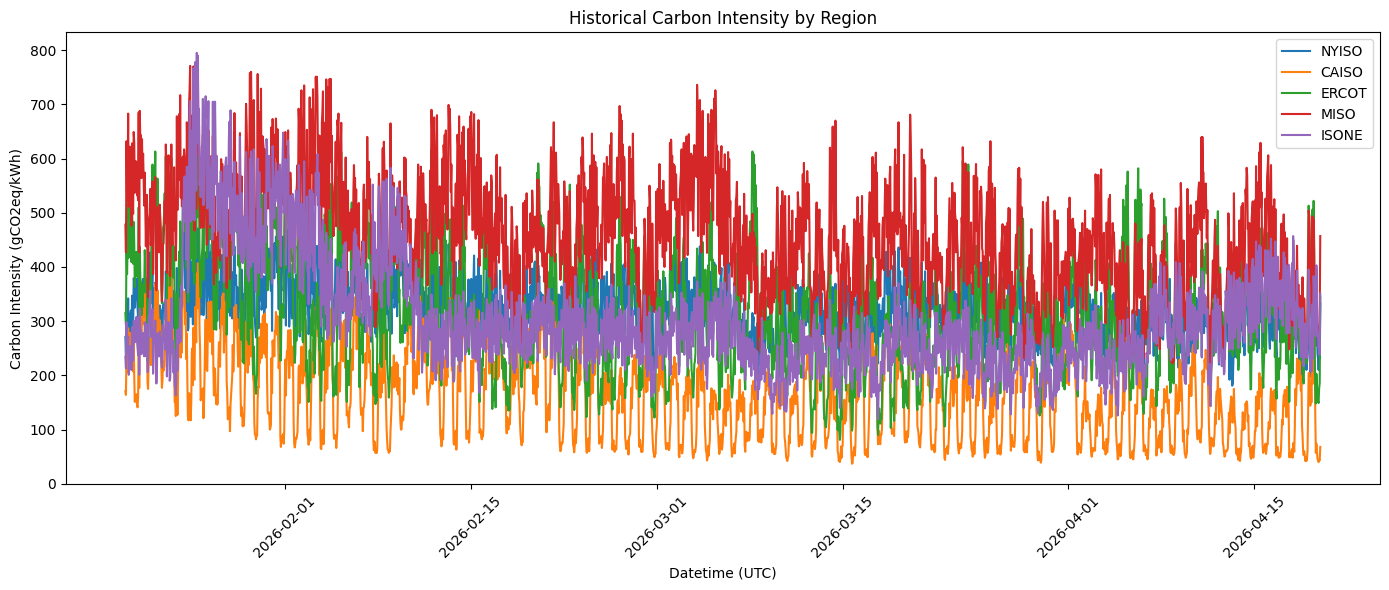

In [ ]:
# ==================================
# Plot historical carbon intensity
# ==================================

plt.figure(figsize=(14, 6))

for region_name in carbon_history_df["region_name"].unique():
    df_region = carbon_history_df[carbon_history_df["region_name"] == region_name]
    plt.plot(df_region["datetime"], df_region["carbonIntensity"], label=region_name)

plt.title("Historical Carbon Intensity by Region")
plt.xlabel("Datetime (UTC)")
plt.ylabel("Carbon Intensity (gCO2eq/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insights from Historical Carbon Intensity by Region

- **Strong and consistent regional differences**
  - CAISO lowest overall, MISO highest, others in mid-range
  - Region choice is a primary driver of emissions impact

- **High volatility within each region**
  - Frequent spikes and dips across all regions
  - Carbon intensity is not stable; forecasting is necessary

- **Clear daily cyclical patterns**
  - Repeating wave-like behavior (especially visible in CAISO)
  - Validates use of lag_24 and hour-based features

- **Weekly/longer-term patterns present**
  - Broader rises and falls over multi-day windows
  - Supports inclusion of lag_168 and day-of-week features

- **CAISO shows strong renewable-driven dips**
  - Regular deep drops (likely solar-driven midday effects)
  - Indicates high potential for low-carbon scheduling windows

- **MISO consistently high with large spikes**
  - Frequent peaks above 600–700 gCO₂/kWh
  - High-emission risk region; important to avoid when possible

- **Intermediate regions (NYISO, ERCOT, ISONE) show mixed behavior**
  - Moderate baseline with both spikes and dips
  - These benefit most from time-aware scheduling

- **Noise + irregular spikes across all regions**
  - Sudden jumps not perfectly predictable
  - Justifies rolling averages and robust modeling approach

- **Seasonal or slow trend shifts over time**
  - Gradual changes in baseline levels across months
  - Supports inclusion of month/seasonal features

- **Overall takeaway**
  - Carbon intensity is both **region-dependent and time-dependent with strong temporal structure**
  - Confirms need for feature-based forecasting + multi-region scheduling

### 3.3 Feature Engineering

I construct lag-based and time-based features to capture:
- short-term dynamics (lag_1)
- daily cycles (lag_24)
- weekly cycles (lag_168)
- temporal patterns (hour, day, month)

In [ ]:
# ============================================================
# Forecast feature engineering:
# lags, rolling means, calendar features, and cyclical relationships
# ============================================================

def add_time_series_features(df):
    """
    Creates the input features the forecasting model will use to predict future
    carbon intensity. Do feature engineering here because raw timestamps and
    raw carbon values alone are not enough for a standard supervised ML model
    to learn temporal patterns directly.

    Inputs:
        - df: DataFrame with datetime, carbonIntensity, and region_name columns

    Outputs:
        - DataFrame with added lag, rolling, calendar, and cyclical time features
    """

    # Sort by region and time first so all lag/rolling features are built in the right order
    # because time-series features only make sense in true chronological order
    df = df.sort_values(["region_name", "datetime"]).copy()

    # 1-hour lag: gives the model the most recent carbon intensity value
    # This helps capture short-term persistence, since the next hour often looks like the last one
    df["lag_1"] = df.groupby("region_name")["carbonIntensity"].shift(1)

    # 24-hour lag: gives the value from the same hour yesterday
    # This helps capture daily repeating patterns in grid behavior and demand/generation cycles
    df["lag_24"] = df.groupby("region_name")["carbonIntensity"].shift(24)

    # 168-hour lag: gives the value from the same hour one week ago
    # This helps capture weekly seasonality, like weekday/weekend effects
    df["lag_168"] = df.groupby("region_name")["carbonIntensity"].shift(168)

    # 24-hour rolling mean: gives a smoothed recent average instead of one single point
    # We shift by 1 first so the feature only uses past data and doesn’t leak the current hour
    df["rolling_mean_24"] = (
        df.groupby("region_name")["carbonIntensity"]
        .shift(1)
        .rolling(window=24)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Hour of day: lets the model learn intraday patterns
    df["hour"] = df["datetime"].dt.hour

    # Day of week: lets the model learn weekday vs weekend behavior
    df["day_of_week"] = df["datetime"].dt.dayofweek

    # Month: gives a simple seasonal signal for broader time-of-year effects
    df["month"] = df["datetime"].dt.month

    # Sine transform of hour: encodes hour-of-day as cyclical instead of linear
    # ex. 23:00 and 0:00 are close in time, even though their raw numbers are far apart
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)

    # Cosine transform of hour: pairs with sine to fully represent the daily cycle
    # hour_sin and hour_cos preserve circular time structure better than raw hour alone
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Sine transform of day-of-week: encodes weekly position cyclically
    # helps the model understand that Sunday and Monday are neighbors in the weekly cycle
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)

    # Cosine transform of day-of-week: second half of the weekly cyclical encoding
    # Using both sine and cosine avoids fake jumps between the ends of the week
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    # Return the  DataFrame so it can be used for model training
    return df

In [ ]:
# ============================================================
# Prepare modeling dataset
# ============================================================

"""
Builds the final dataset used to train the forecasting model by
applying feature engineering and removing incomplete rows.

Inputs:
    - carbon_history_df: raw historical carbon intensity data

Outputs:
    - forecast_model_df: clean, fully-featured dataset ready for ML training
    - prints dataset shape and preview for sanity checking
"""

# Apply feature engineering to create all lag, rolling, and time-based features
forecast_model_df = add_time_series_features(carbon_history_df)

# Drop rows with missing values (these come from lag/rolling features at the start)
forecast_model_df = forecast_model_df.dropna().reset_index(drop=True)

# Print shape to understand how much data remains after feature engineering + cleaning
print(forecast_model_df.shape)

# Preview first few rows to confirm features look correct
forecast_model_df.head()

(9960, 17)


,datetime,zone,carbonIntensity,isEstimated,estimationMethod,region_name,lag_1,lag_24,lag_168,rolling_mean_24,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2026-01-27 00:00:00+00:00,US-CAL-CISO,225,True,SANDBOX_MODE_DATA,CAISO,151.0,267.0,171.0,452.583333,0,1,1,0.000000,1.000000,0.781831,0.62349
1,2026-01-27 01:00:00+00:00,US-CAL-CISO,261,True,SANDBOX_MODE_DATA,CAISO,225.0,303.0,164.0,449.666667,1,1,1,0.258819,0.965926,0.781831,0.62349
2,2026-01-27 02:00:00+00:00,US-CAL-CISO,251,True,SANDBOX_MODE_DATA,CAISO,261.0,248.0,246.0,445.833333,2,1,1,0.500000,0.866025,0.781831,0.62349
3,2026-01-27 03:00:00+00:00,US-CAL-CISO,216,True,SANDBOX_MODE_DATA,CAISO,251.0,211.0,206.0,445.541667,3,1,1,0.707107,0.707107,0.781831,0.62349
4,2026-01-27 04:00:00+00:00,US-CAL-CISO,284,True,SANDBOX_MODE_DATA,CAISO,216.0,208.0,223.0,444.750000,4,1,1,0.866025,0.500000,0.781831,0.62349


### 3.4 Train / Validation Split

We use a chronological split to preserve time-series structure and avoid data leakage.

In [ ]:
# ============================================================
# Chronological train/validation split
# ============================================================

"""
Splits the dataset into training and validation sets based on time.
We use a chronological split (not random) to simulate real forecasting.

Inputs:
    - forecast_model_df: feature-engineered time series dataset

Outputs:
    - train_df: data used to train the model
    - valid_df: most recent data used to evaluate future performance
"""

# Number of most recent days to hold out for validation
VALIDATION_DAYS = 7

# Define cutoff: everything after this is "future" (validation)
cutoff_time = forecast_model_df["datetime"].max() - pd.Timedelta(days=VALIDATION_DAYS)

# Training data = all data up to the cutoff (past data the model is allowed to learn from)
train_df = forecast_model_df[forecast_model_df["datetime"] <= cutoff_time].copy()

# Validation data = the most recent 7 days (simulates unseen future)
valid_df = forecast_model_df[forecast_model_df["datetime"] > cutoff_time].copy()

# Print sizes to verify split looks reasonable
print("Train rows:", len(train_df))
print("Validation rows:", len(valid_df))

# Check boundary alignment to ensure no leakage or overlap
print("Train max datetime:", train_df["datetime"].max())
print("Validation min datetime:", valid_df["datetime"].min())

Train rows: 9120
Validation rows: 840
Train max datetime: 2026-04-12 23:00:00+00:00
Validation min datetime: 2026-04-13 00:00:00+00:00


In [ ]:
# ============================================================
# Features and target
# ============================================================

"""
Defines the input features and prediction target for the model,
then splits both training and validation datasets into X (features)
and y (target).

Inputs:
    - train_df, valid_df: time-based split datasets

Outputs:
    - X_train, y_train: training features and labels
    - X_valid, y_valid: validation features and labels
"""

# List of feature columns the model will use as inputs
# These were engineered earlier to capture temporal patterns
feature_cols = [
    "lag_1",            # recent value (short-term memory)
    "lag_24",           # same hour yesterday (daily pattern)
    "lag_168",          # same hour last week (weekly pattern)
    "rolling_mean_24",  # smoothed recent trend
    "hour",             # raw hour of day
    "day_of_week",      # weekday vs weekend signal
    "month",            # seasonal signal
    "hour_sin",         # cyclical encoding of hour
    "hour_cos",         # cyclical encoding of hour
    "dow_sin",          # cyclical encoding of day of week
    "dow_cos"           # cyclical encoding of day of week
]

# Target variable we want to predict: actual carbon intensity at each timestamp
target_col = "carbonIntensity"

# Extract training inputs (X) using selected feature columns
X_train = train_df[feature_cols]

# Extract training targets (y), what the model learns to predict
y_train = train_df[target_col]

# Extract validation inputs (X) for evaluation
X_valid = valid_df[feature_cols]

# Extract validation targets (y) for comparison against predictions
y_valid = valid_df[target_col]

# Print shapes to confirm dimensions match expectations
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (9120, 11)
X_valid shape: (840, 11)


### 3.5 Forecasting Models

Compare:
- Seasonal naive baseline
- Linear regression model

This allows us to evaluate whether learning improves forecasting accuracy.

In [ ]:
# ============================================================
# Seasonal naive baseline
# ============================================================

def seasonal_naive_predictions(df):
    """
    Generates baseline predictions using a seasonal naive approach.
    Assumes the best prediction for the current hour is the value from the same hour yesterday.

    Inputs:
        - df: DataFrame containing at least the lag_24 feature

    Outputs:
        - numpy array of predictions based on lag_24 values
    """

    # Simply return the value from 24 hours ago as the prediction
    # This leverages daily seasonality and acts as a strong, simple baseline
    return df["lag_24"].values

In [ ]:
# ============================================================
# Linear regression forecaster
# ============================================================

"""
Trains a simple linear regression model to forecast carbon intensity,
then evaluates it against a seasonal naive baseline using MAE and RMSE.

Inputs:
    - X_train, y_train: training features and targets
    - X_valid, y_valid: validation features and targets

Outputs:
    - validation predictions for both models
    - MAE and RMSE metrics for comparison
"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize a linear regression model (learns weighted combination of features)
lr_forecaster = LinearRegression()

# Fit the model on training data (learn relationships between features and target)
lr_forecaster.fit(X_train, y_train)

# Generate predictions on validation set using trained model
valid_pred_lr = lr_forecaster.predict(X_valid)

# Generate baseline predictions using seasonal naive approach (yesterday’s value)
valid_pred_naive = seasonal_naive_predictions(valid_df)

# Compute MAE for naive model (average absolute error)
mae_naive = mean_absolute_error(y_valid, valid_pred_naive)

# Compute RMSE for naive model (penalizes large errors more)
rmse_naive = mean_squared_error(y_valid, valid_pred_naive) ** 0.5

# Compute MAE for linear regression model
mae_lr = mean_absolute_error(y_valid, valid_pred_lr)

# Compute RMSE for linear regression model
rmse_lr = mean_squared_error(y_valid, valid_pred_lr) ** 0.5

# Print comparison results clearly
print("Forecasting Validation Results")
print("=" * 50)
print(f"Seasonal Naive - MAE:  {mae_naive:.3f}")
print(f"Seasonal Naive - RMSE: {rmse_naive:.3f}")
print(f"Linear Regression - MAE:  {mae_lr:.3f}")
print(f"Linear Regression - RMSE: {rmse_lr:.3f}")

Forecasting Validation Results
Seasonal Naive - MAE:  59.292
Seasonal Naive - RMSE: 78.494
Linear Regression - MAE:  47.278
Linear Regression - RMSE: 60.227


### 3.6 Forecast Evaluation

We evaluate model performance using:
- visual comparison
- MAE / RMSE metrics
- region-level breakdowns

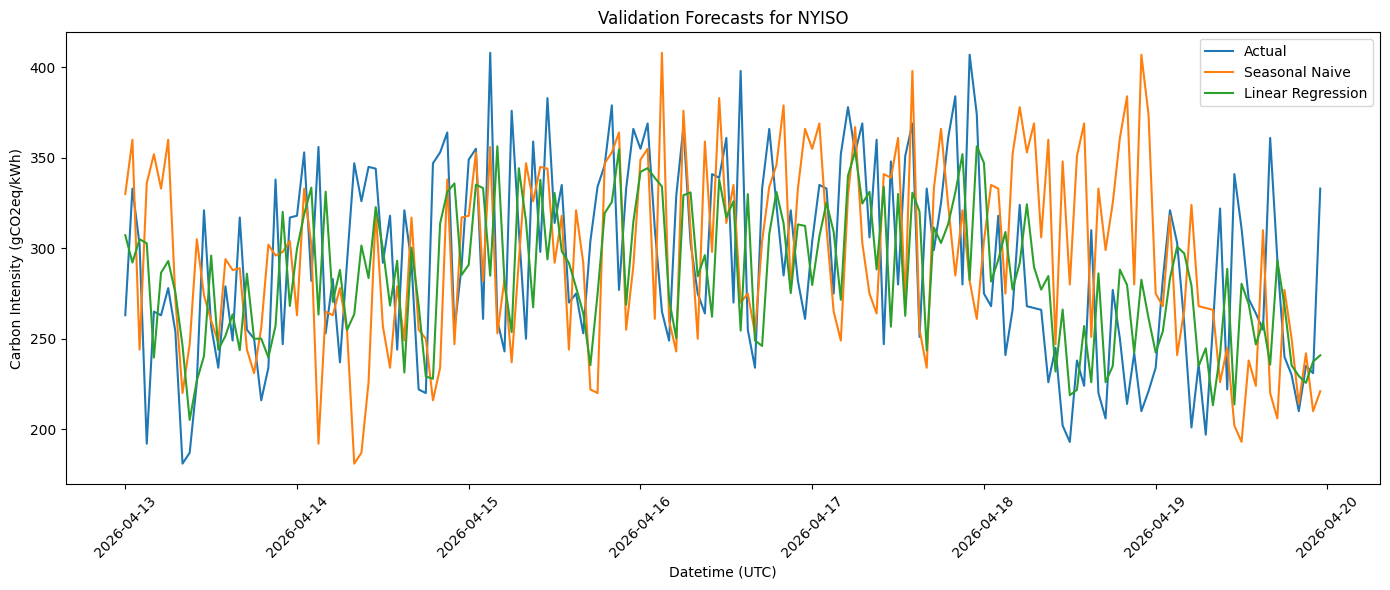

In [ ]:
# ============================================================
# Plot actual vs predicted on validation window
# ============================================================

plot_valid_df = valid_df.copy()
plot_valid_df["pred_naive"] = valid_pred_naive
plot_valid_df["pred_lr"] = valid_pred_lr

# Plot one region first for readability
region_to_plot = "NYISO"
plot_region_df = plot_valid_df[plot_valid_df["region_name"] == region_to_plot].copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_region_df["datetime"], plot_region_df["carbonIntensity"], label="Actual")
plt.plot(plot_region_df["datetime"], plot_region_df["pred_naive"], label="Seasonal Naive")
plt.plot(plot_region_df["datetime"], plot_region_df["pred_lr"], label="Linear Regression")

plt.title(f"Validation Forecasts for {region_to_plot}")
plt.xlabel("Datetime (UTC)")
plt.ylabel("Carbon Intensity (gCO2eq/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insights from Validation Forecasts (NYISO)

- **Linear regression tracks overall trend better than naive**
  - Green line follows general direction of actual values more consistently
  - Model is learning meaningful structure beyond simple repetition

- **Seasonal naive captures daily pattern but is more erratic**
  - Orange line often overshoots and undershoots sharply
  - Using only yesterday's value is too rigid and noisy

- **Linear regression is smoother and more stable**
  - Produces less extreme swings compared to naive
  - Rolling and lag features help reduce noise impact

- **Both models struggle with sharp spikes**
  - Neither model consistently captures sudden peaks or drops
  - Indicates limits of linear + lag-based approach for extreme events

- **Naive model sometimes closer at exact peaks**
  - Occasionally matches spikes better than linear regression
  - Suggests strong short-term persistence in some periods

- **Linear regression performs better on average behavior**
  - Better alignment in mid-range values (~250-330)
  - Improves overall error metrics (MAE/RMSE)

- **Evidence of daily seasonality in actual data**
  - Repeating up/down cycles visible in blue line
  - Validates feature choices like lag_24 and hour-based features

- **Residual noise remains significant**
  - Actual values fluctuate unpredictably at times
  - Explains why perfect prediction is not achievable

- **Overall takeaway**
  - Linear regression improves over the naive baseline by capturing broader trends and smoothing noise, but both models struggle with high-frequency volatility
  - Strong foundation, but room for improvement with more advanced models (e.g., boosting, sequence models)

In [ ]:
# ============================================================
# Region-level validation metrics
# ============================================================

region_metrics = []

for region_name in valid_df["region_name"].unique():
    df_region = valid_df[valid_df["region_name"] == region_name].copy()
    X_region = df_region[feature_cols]
    y_region = df_region[target_col]

    pred_lr_region = lr_forecaster.predict(X_region)
    pred_naive_region = seasonal_naive_predictions(df_region)

    region_metrics.append({
        "region_name": region_name,
        "naive_mae": mean_absolute_error(y_region, pred_naive_region),
        "naive_rmse": mean_squared_error(y_region, pred_naive_region) ** 0.5,
        "lr_mae": mean_absolute_error(y_region, pred_lr_region),
        "lr_rmse": mean_squared_error(y_region, pred_lr_region) ** 0.5
    })

region_metrics_df = pd.DataFrame(region_metrics)
region_metrics_df

,region_name,naive_mae,naive_rmse,lr_mae,lr_rmse
0,CAISO,23.738095,32.773211,25.688632,31.536093
1,ERCOT,64.755952,84.221964,50.266299,61.655617
2,ISONE,66.541667,80.859998,51.920729,63.458336
3,MISO,83.839286,104.291744,64.042750,79.474492
4,NYISO,57.583333,72.276585,44.470870,54.747039


### Key Insights from Region-Level Validation Metrics

- **Linear regression outperforms naive in most regions**
  - Lower MAE and RMSE in ERCOT, ISONE, MISO, NYISO
  - Model is consistently learning useful structure beyond simple baselines

- **Exception: CAISO where naive slightly outperforms**
  - Naive MAE (23.7) vs LR MAE (25.7)
  - Strong daily regularity makes lag_24 hard to beat

- **Largest improvements in high-variability regions**
  - MISO, ERCOT show biggest error reductions
  - Model adds most value where patterns are more complex

- **NYISO and ISONE show solid mid-range gains**
  - Meaningful reduction in both MAE and RMSE
  - Feature engineering is effective for these regions

- **RMSE improvements confirm better handling of large errors**
  - LR consistently lowers RMSE vs naive
  - →Model reduces impact of large spikes more effectively

- **Regional difficulty varies significantly**
  - CAISO easiest (lowest errors)
  - MISO hardest (highest errors)
  - Reflects underlying grid stability vs volatility

- **Naive baseline remains strong in highly seasonal regions**
  - Especially CAISO
  - Confirms importance of daily cyclic patterns

- **Overall takeaway**
  - Linear regression provides consistent improvement across most regions, especially where variability is higher, validating the feature-based modeling approach while highlighting that highly regular regions may require less complex models

In [ ]:
# ============================================================
# Recursive next-24-hour forecasting:
# predict one step ahead, then use that prediction as input for the next step, keep repeating
# ============================================================

def make_recursive_forecast_for_region(region_name, history_df, model, horizon_hours=24):
    """
    Generates future hourly carbon-intensity forecasts for one region by
    repeatedly predicting one hour ahead and feeding each prediction back in
    as history for the next step.

    Inputs:
        - region_name: region to forecast, like "NYISO"
        - history_df: historical carbon data with datetime, carbonIntensity, and region_name
        - model: trained forecasting model
        - horizon_hours: number of future hours to predict

    Outputs:
        - DataFrame of future predicted carbon intensity values for that region
    """

    # Filter down to just this region’s history
    df_region = history_df[history_df["region_name"] == region_name].copy()

    # Sort in time order so lag logic works correctly
    df_region = df_region.sort_values("datetime").reset_index(drop=True)

    # Need at least 168 hours of history because one feature is lag_168
    if len(df_region) < 168:
        raise ValueError(f"Not enough history for recursive forecasting in region {region_name}")

    # Start with the known historical carbon values for this region
    working_values = list(df_region["carbonIntensity"].values)

    # Get the latest known timestamp so we know where forecasting starts
    last_datetime = df_region["datetime"].max()

    # Store each newly predicted future row here
    future_rows = []

    # Predict one future hour at a time until we reach the full forecast horizon
    for step in range(1, horizon_hours + 1):

        # The timestamp we are currently forecasting
        future_datetime = last_datetime + pd.Timedelta(hours=step)

        # Build lag features from the most recent available values
        # At first these come from real history; later some come from past predictions
        lag_1 = working_values[-1]
        lag_24 = working_values[-24]
        lag_168 = working_values[-168]

        # Compute rolling recent average from the last 24 available values
        rolling_mean_24 = np.mean(working_values[-24:])

        # Extract calendar features for the future timestamp
        hour = future_datetime.hour
        day_of_week = future_datetime.dayofweek
        month = future_datetime.month

        # Encode hour cyclically so nearby times stay nearby mathematically
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        # Encode day-of-week cyclically for weekly seasonality
        dow_sin = np.sin(2 * np.pi * day_of_week / 7)
        dow_cos = np.cos(2 * np.pi * day_of_week / 7)

        # Package this single future timestamp as one feature row for prediction
        X_future = pd.DataFrame([{
            "lag_1": lag_1,
            "lag_24": lag_24,
            "lag_168": lag_168,
            "rolling_mean_24": rolling_mean_24,
            "hour": hour,
            "day_of_week": day_of_week,
            "month": month,
            "hour_sin": hour_sin,
            "hour_cos": hour_cos,
            "dow_sin": dow_sin,
            "dow_cos": dow_cos
        }])

        # Predict carbon intensity for this one future hour
        pred = model.predict(X_future)[0]

        # Save that forecasted row
        future_rows.append({
            "datetime": future_datetime,
            "carbonIntensity": pred,
            "region_name": region_name
        })

        # Append the prediction so later future steps can use it as lag history
        # This is what makes the forecast recursive
        working_values.append(pred)

    # Convert all predicted future rows into a DataFrame
    future_df = pd.DataFrame(future_rows)

    # Return the full future forecast for this region
    return future_df

### 3.7 Future Forecast Generation

We generate 24-hour ahead forecasts using recursive prediction.

These forecasts are used as inputs to the scheduling system.

In [ ]:
# ============================================================
# Generate next-24-hour forecasts for all regions
# ============================================================

"""
Generates model-based next-24-hour carbon forecasts for every region
using the trained forecasting model, then combines them into one table
for downstream scheduling use.

Inputs:
    - carbon_history_df: historical carbon data for all regions
    - lr_forecaster: trained forecasting model

Outputs:
    - carbon_forecast_df: combined DataFrame of next-24-hour forecasts for all regions
    - prints success/failure logs and basic forecast checks
"""

# Store each region’s future forecast before combining
all_model_forecasts = []

# Loop through every region present in the historical dataset
for region_name in carbon_history_df["region_name"].unique():
    try:
        # Generate the next 24 hourly forecasts for this region
        future_df = make_recursive_forecast_for_region(
            region_name=region_name,
            history_df=carbon_history_df,
            model=lr_forecaster,
            horizon_hours=24
        )

        # Save this region’s forecast
        all_model_forecasts.append(future_df)

        # Log success so we know the region completed correctly
        print(f"Success: generated forecast for {region_name}")

    except Exception as e:
        # Log failure so we can debug missing history or model issues
        print(f"Failed: {region_name}")
        print(e)

# Combine all regional forecast DataFrames into one scheduler-ready table
carbon_forecast_df = pd.concat(all_model_forecasts, ignore_index=True)

# Preview the first few forecast rows to verify structure
print(carbon_forecast_df.head())

# Show how many forecasted hours were created per region
print()
print(carbon_forecast_df.groupby("region_name").size())

Success: generated forecast for NYISO
Success: generated forecast for CAISO
Success: generated forecast for ERCOT
Success: generated forecast for MISO
Success: generated forecast for ISONE
                   datetime  carbonIntensity region_name
0 2026-04-20 00:00:00+00:00       304.256306       NYISO
1 2026-04-20 01:00:00+00:00       306.778981       NYISO
2 2026-04-20 02:00:00+00:00       314.532184       NYISO
3 2026-04-20 03:00:00+00:00       304.643418       NYISO
4 2026-04-20 04:00:00+00:00       297.083078       NYISO

region_name
CAISO    24
ERCOT    24
ISONE    24
MISO     24
NYISO    24
dtype: int64


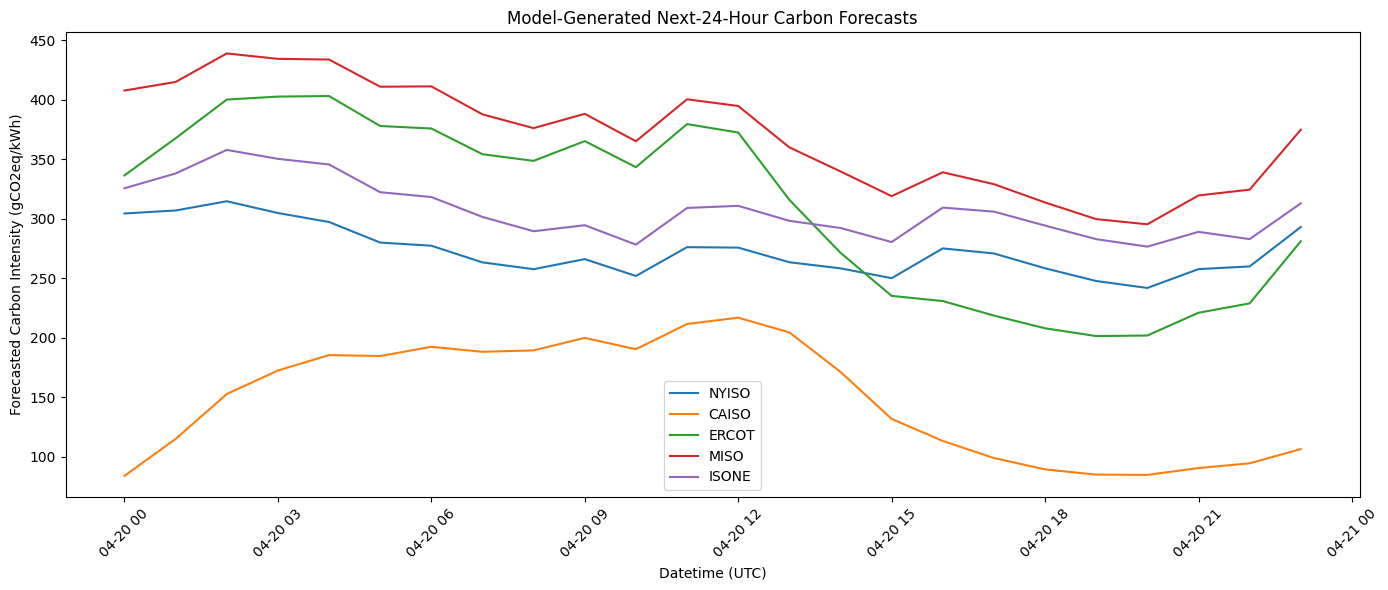

In [ ]:
# ============================================================
# Plot model-generated next-24-hour forecasts
# ============================================================

plt.figure(figsize=(14, 6))

for region_name in carbon_forecast_df["region_name"].unique():
    df_region = carbon_forecast_df[carbon_forecast_df["region_name"] == region_name]
    plt.plot(df_region["datetime"], df_region["carbonIntensity"], label=region_name)

plt.title("Model-Generated Next-24-Hour Carbon Forecasts")
plt.xlabel("Datetime (UTC)")
plt.ylabel("Forecasted Carbon Intensity (gCO2eq/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insights from Model-Generated Next-24-Hour Forecasts

- **Clear regional separation persists in forecasts**
  - CAISO lowest, MISO highest, others in between
  - Model preserves learned regional differences from historical data

- **Smooth, stable forecast curves**
  - Compared to historical data, forecasts are less noisy
  - Linear regression + rolling features effectively smooth short-term volatility

- **Strong daily cyclical patterns captured**
  - All regions show gradual rise/fall across the day
  - Confirms model learned time-of-day structure (hour, lag_24, cyclical features)

- **Midday dips and peaks vary by region**
  - CAISO dips significantly, ERCOT drops later, others moderate
  - Model captures region-specific temporal behavior

- **No extreme spikes or sharp jumps**
  - Forecasts avoid sudden volatility seen in real data
  - Indicates limitation: model underestimates extreme events

- **Consistent relative ordering across time**
  - Regions maintain similar ranking (CAISO < NYISO/ISONE < ERCOT < MISO)
  - Model encodes stable structural differences between grids

- **Gradual transitions between hours**
  - No abrupt hour-to-hour changes
  - Reflects reliance on lag and rolling features

- **End-of-horizon upward trends in several regions**
  - Slight increases toward final hours
  - Could reflect learned late-day demand patterns or recursive drift

- **Evidence of recursive forecasting effects**
  - Later predictions appear more smoothed and slightly biased
  - Small errors accumulate across forecast horizon

- **Overall takeaway**
  - Model successfully captures broad temporal patterns and regional differences, producing stable and interpretable forecasts, but lacks the ability to model sharp volatility and extreme events

## 4. API-Based Scheduler Experiments

Here I evaluate scheduling decisions using real-world forecasts from Electricity Maps.

Compare:
- baseline scheduler (run immediately)
- carbon-aware scheduler (optimize for emissions)

In [ ]:
# ===========================
# Hardcode an example job
# ===========================

job_1 = MLJob(
    job_id="job_001",
    submission_time=pd.Timestamp.utcnow().floor("h"),
    deadline=pd.Timestamp.utcnow().floor("h") + pd.Timedelta(hours=18),
    max_delay_hours=8,
    runtime_hours=4,
    total_energy_kwh=12.0,
    default_region="NYISO",
    allowed_regions=["NYISO", "CAISO", "ERCOT", "MISO", "ISONE"]
)

print(job_1)

MLJob(job_id='job_001', submission_time=Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), deadline=Timestamp('2026-04-20 18:00:00+0000', tz='UTC'), max_delay_hours=8, runtime_hours=4, total_energy_kwh=12.0, default_region='NYISO', allowed_regions=['NYISO', 'CAISO', 'ERCOT', 'MISO', 'ISONE'])


In [ ]:
# Test feasible start times
feasible_starts = get_feasible_start_times(job_1)

print("Feasible start times:")
for t in feasible_starts:
    print(t)


Feasible start times:
2026-04-20 00:00:00+00:00
2026-04-20 01:00:00+00:00
2026-04-20 02:00:00+00:00
2026-04-20 03:00:00+00:00
2026-04-20 04:00:00+00:00
2026-04-20 05:00:00+00:00
2026-04-20 06:00:00+00:00
2026-04-20 07:00:00+00:00
2026-04-20 08:00:00+00:00


### Emissions calculation
- assume energy is spread evenly across runtime, so we can use: energy per hour = total energy / runtime hours
- and then total emissions=∑(energy per hour×carbon intensity)

### 4.1 Single Job Analysis

We walk through a single job to understand:
- feasible start times
- emissions calculation
- scheduling decision logic

In [ ]:
#############################
# Test one candidate schedule
#############################

test_region = "NYISO"
feasible_starts = get_feasible_start_times(job_1)
test_start = feasible_starts[0]

test_emissions = calculate_schedule_emissions(job_1, test_region, test_start, carbon_forecast_api_df)

print("Test region:", test_region)
print("Test start:", test_start)
print("Predicted emissions (gCO2eq):", test_emissions)


Test region: NYISO
Test start: 2026-04-20 00:00:00+00:00
Predicted emissions (gCO2eq): 3105.0


### Decision engine: build the carbon-aware scheduler

In [ ]:
#####################
# Run scheduler
#####################

schedule_result = carbon_aware_schedule(job_1, carbon_forecast_api_df)

best_schedule = schedule_result["best_schedule"]
candidates_df = schedule_result["candidates_df"]

print("Best schedule:")
print(best_schedule)


Best schedule:
{'job_id': 'job_001', 'region_name': 'CAISO', 'start_time': Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), 'finish_time': Timestamp('2026-04-20 04:00:00+0000', tz='UTC'), 'delay_hours': 0, 'runtime_hours': 4, 'total_energy_kwh': 12.0, 'predicted_emissions_gco2': 1416.0}


In [ ]:
#################################
# Inspect top candidate schedules
#################################
candidates_df.head(10)

,job_id,region_name,start_time,finish_time,delay_hours,runtime_hours,total_energy_kwh,predicted_emissions_gco2
0,job_001,CAISO,2026-04-20 00:00:00+00:00,2026-04-20 04:00:00+00:00,0,4,12.0,1416.0
1,job_001,CAISO,2026-04-20 01:00:00+00:00,2026-04-20 05:00:00+00:00,1,4,12.0,1716.0
2,job_001,CAISO,2026-04-20 03:00:00+00:00,2026-04-20 07:00:00+00:00,3,4,12.0,2064.0
3,job_001,CAISO,2026-04-20 02:00:00+00:00,2026-04-20 06:00:00+00:00,2,4,12.0,2085.0
4,job_001,CAISO,2026-04-20 04:00:00+00:00,2026-04-20 08:00:00+00:00,4,4,12.0,2172.0
5,job_001,CAISO,2026-04-20 05:00:00+00:00,2026-04-20 09:00:00+00:00,5,4,12.0,2352.0
6,job_001,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 10:00:00+00:00,6,4,12.0,2394.0
7,job_001,CAISO,2026-04-20 08:00:00+00:00,2026-04-20 12:00:00+00:00,8,4,12.0,2535.0
8,job_001,CAISO,2026-04-20 07:00:00+00:00,2026-04-20 11:00:00+00:00,7,4,12.0,2562.0
9,job_001,ISONE,2026-04-20 00:00:00+00:00,2026-04-20 04:00:00+00:00,0,4,12.0,3042.0


In [ ]:
####################################
# Compare baseline vs carbon aware
####################################

baseline_result = baseline_schedule(job_1, carbon_forecast_api_df)

print("Baseline schedule:")
print(baseline_result)

print("\nCarbon-aware best schedule:")
print(best_schedule)


Baseline schedule:
{'job_id': 'job_001', 'region_name': 'NYISO', 'start_time': Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), 'finish_time': Timestamp('2026-04-20 04:00:00+0000', tz='UTC'), 'delay_hours': 0, 'runtime_hours': 4, 'total_energy_kwh': 12.0, 'predicted_emissions_gco2': np.float64(3105.0)}

Carbon-aware best schedule:
{'job_id': 'job_001', 'region_name': 'CAISO', 'start_time': Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), 'finish_time': Timestamp('2026-04-20 04:00:00+0000', tz='UTC'), 'delay_hours': 0, 'runtime_hours': 4, 'total_energy_kwh': 12.0, 'predicted_emissions_gco2': 1416.0}


In [ ]:
# Run comparison
comparison = compare_schedulers(baseline_result, best_schedule)

print("Scheduler comparison:")
print(comparison)

display_schedule_result("Baseline Schedule (API Forecast)", baseline_result)
display_schedule_result("Carbon-Aware Best Schedule (API Forecast)", best_schedule)
display_schedule_result("Comparison Summary (API Forecast)", comparison)


Scheduler comparison:
{'baseline_emissions_gco2': np.float64(3105.0), 'carbon_aware_emissions_gco2': 1416.0, 'absolute_savings_gco2': np.float64(1689.0), 'percent_savings': np.float64(54.39613526570049), 'added_delay_hours': 0, 'baseline_region': 'NYISO', 'carbon_aware_region': 'CAISO', 'baseline_start_time': Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), 'carbon_aware_start_time': Timestamp('2026-04-20 00:00:00+0000', tz='UTC')}
Baseline Schedule (API Forecast)
job_id: job_001
region_name: NYISO
start_time: 2026-04-20 00:00:00+00:00
finish_time: 2026-04-20 04:00:00+00:00
delay_hours: 0
runtime_hours: 4
total_energy_kwh: 12.0
predicted_emissions_gco2: 3105.0

Carbon-Aware Best Schedule (API Forecast)
job_id: job_001
region_name: CAISO
start_time: 2026-04-20 00:00:00+00:00
finish_time: 2026-04-20 04:00:00+00:00
delay_hours: 0
runtime_hours: 4
total_energy_kwh: 12.0
predicted_emissions_gco2: 1416.0

Comparison Summary (API Forecast)
baseline_emissions_gco2: 3105.0
carbon_aware_emission

### 4.2 Batch Simulation

We simulate many jobs to evaluate:
- emissions savings
- delay tradeoffs
- region selection behavior

In [ ]:
##################
# Generate a batch
###################
jobs = generate_synthetic_jobs(n_jobs=40)
print(f"Number of jobs generated: {len(jobs)}")
print(jobs[0])

Number of jobs generated: 40
MLJob(job_id='job_001', submission_time=Timestamp('2026-04-20 10:00:00+0000', tz='UTC'), deadline=Timestamp('2026-04-20 16:00:00+0000', tz='UTC'), max_delay_hours=4, runtime_hours=2, total_energy_kwh=3.13, default_region='CAISO', allowed_regions=['NYISO', 'CAISO', 'ERCOT', 'MISO', 'ISONE'])


In [ ]:
# Inspect batch
jobs_df = pd.DataFrame([vars(job) for job in jobs])
jobs_df.head()

,job_id,submission_time,deadline,max_delay_hours,runtime_hours,total_energy_kwh,default_region,allowed_regions
0,job_001,2026-04-20 10:00:00+00:00,2026-04-20 16:00:00+00:00,4,2,3.13,CAISO,"[NYISO, CAISO, ERCOT, MISO, ISONE]"
1,job_002,2026-04-20 02:00:00+00:00,2026-04-20 06:00:00+00:00,8,2,6.38,ISONE,"[NYISO, CAISO, ERCOT, MISO, ISONE]"
2,job_003,2026-04-20 06:00:00+00:00,2026-04-20 12:00:00+00:00,2,2,3.15,ISONE,"[NYISO, CAISO, ERCOT, MISO, ISONE]"
3,job_004,2026-04-20 09:00:00+00:00,2026-04-21 05:00:00+00:00,12,2,5.81,ISONE,"[NYISO, CAISO, ERCOT, MISO, ISONE]"
4,job_005,2026-04-20 06:00:00+00:00,2026-04-21 09:00:00+00:00,4,3,7.87,NYISO,"[NYISO, CAISO, ERCOT, MISO, ISONE]"


In [ ]:
# Run batch experiment
results_df = run_scheduler_experiment(jobs, carbon_forecast_api_df)
results_df.head()


,job_id,submission_time,deadline,max_delay_hours,runtime_hours,total_energy_kwh,default_region,baseline_region,baseline_start_time,baseline_finish_time,...,carbon_region,carbon_start_time,carbon_finish_time,carbon_delay_hours,carbon_emissions_gco2,absolute_savings_gco2,percent_savings,extra_delay_hours,changed_region,changed_start_time
0,job_001,2026-04-20 10:00:00+00:00,2026-04-20 16:00:00+00:00,4,2,3.13,CAISO,CAISO,2026-04-20 10:00:00+00:00,2026-04-20 12:00:00+00:00,...,CAISO,2026-04-20 14:00:00+00:00,2026-04-20 16:00:00+00:00,4,345.865000,283.265000,45.024876,4,False,True
1,job_002,2026-04-20 02:00:00+00:00,2026-04-20 06:00:00+00:00,8,2,6.38,ISONE,ISONE,2026-04-20 02:00:00+00:00,2026-04-20 04:00:00+00:00,...,CAISO,2026-04-20 03:00:00+00:00,2026-04-20 05:00:00+00:00,1,998.470000,835.780000,45.565217,1,True,True
2,job_003,2026-04-20 06:00:00+00:00,2026-04-20 12:00:00+00:00,2,2,3.15,ISONE,ISONE,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,...,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,0,559.125000,207.900000,27.104723,0,True,False
3,job_004,2026-04-20 09:00:00+00:00,2026-04-21 05:00:00+00:00,12,2,5.81,ISONE,ISONE,2026-04-20 09:00:00+00:00,2026-04-20 11:00:00+00:00,...,CAISO,2026-04-20 21:00:00+00:00,2026-04-20 23:00:00+00:00,12,395.080000,1275.295000,76.347826,12,True,True
4,job_005,2026-04-20 06:00:00+00:00,2026-04-21 09:00:00+00:00,4,3,7.87,NYISO,NYISO,2026-04-20 06:00:00+00:00,2026-04-20 09:00:00+00:00,...,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 09:00:00+00:00,0,1513.663333,532.536667,26.025641,0,True,False


In [ ]:
# API experiment summary
summary = summarize_experiment(results_df)

if summary is None:
    print("No valid API experiment results to summarize.")
else:
    print("API Experiment Summary")
    print("=" * 50)
    for key, value in summary.items():
        print(f"{key}: {value}")


API Experiment Summary
num_jobs_evaluated: 40
total_baseline_emissions_gco2: 159510.2425
total_carbon_aware_emissions_gco2: 68937.72333333333
total_absolute_savings_gco2: 90572.51916666668
average_percent_savings: 52.492256108267874
average_extra_delay_hours: 2.975
median_extra_delay_hours: 1.5
jobs_with_region_change_pct: 82.5
jobs_with_start_change_pct: 55.00000000000001


### 4.3 Results and Analysis

Analyze:
- emissions reduction distribution
- delay vs savings tradeoff
- impact of job flexibility
- region selection patterns

In [ ]:
# Sort jobs by emission savings
results_df.sort_values("absolute_savings_gco2", ascending=False).head(10)

,job_id,submission_time,deadline,max_delay_hours,runtime_hours,total_energy_kwh,default_region,baseline_region,baseline_start_time,baseline_finish_time,...,carbon_region,carbon_start_time,carbon_finish_time,carbon_delay_hours,carbon_emissions_gco2,absolute_savings_gco2,percent_savings,extra_delay_hours,changed_region,changed_start_time
28,job_029,2026-04-20 08:00:00+00:00,2026-04-20 22:00:00+00:00,8,8,30.37,MISO,MISO,2026-04-20 08:00:00+00:00,2026-04-20 16:00:00+00:00,...,CAISO,2026-04-20 14:00:00+00:00,2026-04-20 22:00:00+00:00,6,2551.080000,10728.202500,80.789022,6,True,True
30,job_031,2026-04-20 03:00:00+00:00,2026-04-21 05:00:00+00:00,0,8,30.94,MISO,MISO,2026-04-20 03:00:00+00:00,2026-04-20 11:00:00+00:00,...,CAISO,2026-04-20 03:00:00+00:00,2026-04-20 11:00:00+00:00,0,5963.685000,8663.200000,59.227922,0,True,False
31,job_032,2026-04-20 01:00:00+00:00,2026-04-21 03:00:00+00:00,2,8,27.32,MISO,MISO,2026-04-20 01:00:00+00:00,2026-04-20 09:00:00+00:00,...,CAISO,2026-04-20 01:00:00+00:00,2026-04-20 09:00:00+00:00,0,4630.740000,8247.225000,64.041368,0,True,False
19,job_020,2026-04-20 04:00:00+00:00,2026-04-20 20:00:00+00:00,8,8,20.57,ERCOT,ERCOT,2026-04-20 04:00:00+00:00,2026-04-20 12:00:00+00:00,...,CAISO,2026-04-20 12:00:00+00:00,2026-04-20 20:00:00+00:00,8,2419.546250,5165.641250,68.101695,8,True,True
38,job_039,2026-04-20 03:00:00+00:00,2026-04-20 23:00:00+00:00,8,8,14.65,MISO,MISO,2026-04-20 03:00:00+00:00,2026-04-20 11:00:00+00:00,...,CAISO,2026-04-20 11:00:00+00:00,2026-04-20 19:00:00+00:00,8,1909.993750,5015.793750,72.421999,8,True,True
7,job_008,2026-04-20 05:00:00+00:00,2026-04-21 07:00:00+00:00,0,8,17.29,MISO,MISO,2026-04-20 05:00:00+00:00,2026-04-20 13:00:00+00:00,...,CAISO,2026-04-20 05:00:00+00:00,2026-04-20 13:00:00+00:00,0,3535.805000,4475.948750,55.867278,0,True,False
11,job_012,2026-04-20 01:00:00+00:00,2026-04-20 10:00:00+00:00,6,3,11.00,MISO,MISO,2026-04-20 01:00:00+00:00,2026-04-20 04:00:00+00:00,...,CAISO,2026-04-20 01:00:00+00:00,2026-04-20 04:00:00+00:00,0,1503.333333,3699.666667,71.106413,0,True,False
24,job_025,2026-04-20 12:00:00+00:00,2026-04-20 18:00:00+00:00,4,4,13.69,ERCOT,ERCOT,2026-04-20 12:00:00+00:00,2026-04-20 16:00:00+00:00,...,CAISO,2026-04-20 14:00:00+00:00,2026-04-20 18:00:00+00:00,2,1283.437500,3131.587500,70.930233,2,True,True
22,job_023,2026-04-20 01:00:00+00:00,2026-04-20 19:00:00+00:00,6,6,14.72,ERCOT,ERCOT,2026-04-20 01:00:00+00:00,2026-04-20 07:00:00+00:00,...,CAISO,2026-04-20 01:00:00+00:00,2026-04-20 07:00:00+00:00,0,2323.306667,2968.533333,56.096430,0,True,False
33,job_034,2026-04-20 08:00:00+00:00,2026-04-21 05:00:00+00:00,6,3,9.85,ERCOT,ERCOT,2026-04-20 08:00:00+00:00,2026-04-20 11:00:00+00:00,...,CAISO,2026-04-20 14:00:00+00:00,2026-04-20 17:00:00+00:00,6,1007.983333,2909.033333,74.266555,6,True,True


- almost all start in high-carbon regions (MISO or ERCOT)
- many switch to CAISO
- many have long runtimes

In [ ]:
# Jobs with little or no improvement
results_df.sort_values("absolute_savings_gco2", ascending=True).head(10)

,job_id,submission_time,deadline,max_delay_hours,runtime_hours,total_energy_kwh,default_region,baseline_region,baseline_start_time,baseline_finish_time,...,carbon_region,carbon_start_time,carbon_finish_time,carbon_delay_hours,carbon_emissions_gco2,absolute_savings_gco2,percent_savings,extra_delay_hours,changed_region,changed_start_time
35,job_036,2026-04-20 05:00:00+00:00,2026-04-20 19:00:00+00:00,2,2,5.94,CAISO,CAISO,2026-04-20 05:00:00+00:00,2026-04-20 07:00:00+00:00,...,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,1,1054.350000,59.400000,5.333333,1,False,True
2,job_003,2026-04-20 06:00:00+00:00,2026-04-20 12:00:00+00:00,2,2,3.15,ISONE,ISONE,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,...,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,0,559.125000,207.900000,27.104723,0,True,False
0,job_001,2026-04-20 10:00:00+00:00,2026-04-20 16:00:00+00:00,4,2,3.13,CAISO,CAISO,2026-04-20 10:00:00+00:00,2026-04-20 12:00:00+00:00,...,CAISO,2026-04-20 14:00:00+00:00,2026-04-20 16:00:00+00:00,4,345.865000,283.265000,45.024876,4,False,True
13,job_014,2026-04-20 11:00:00+00:00,2026-04-21 01:00:00+00:00,2,2,6.05,CAISO,CAISO,2026-04-20 11:00:00+00:00,2026-04-20 13:00:00+00:00,...,CAISO,2026-04-20 13:00:00+00:00,2026-04-20 15:00:00+00:00,2,934.725000,296.450000,24.078624,2,False,True
9,job_010,2026-04-20 04:00:00+00:00,2026-04-21 00:00:00+00:00,4,8,29.71,CAISO,CAISO,2026-04-20 04:00:00+00:00,2026-04-20 12:00:00+00:00,...,CAISO,2026-04-20 08:00:00+00:00,2026-04-20 16:00:00+00:00,4,5503.777500,323.096250,5.544933,4,False,True
23,job_024,2026-04-20 08:00:00+00:00,2026-04-21 04:00:00+00:00,0,2,6.40,ISONE,ISONE,2026-04-20 08:00:00+00:00,2026-04-20 10:00:00+00:00,...,CAISO,2026-04-20 08:00:00+00:00,2026-04-20 10:00:00+00:00,0,1417.600000,432.000000,23.356401,0,True,False
4,job_005,2026-04-20 06:00:00+00:00,2026-04-21 09:00:00+00:00,4,3,7.87,NYISO,NYISO,2026-04-20 06:00:00+00:00,2026-04-20 09:00:00+00:00,...,CAISO,2026-04-20 06:00:00+00:00,2026-04-20 09:00:00+00:00,0,1513.663333,532.536667,26.025641,0,True,False
8,job_009,2026-04-20 08:00:00+00:00,2026-04-20 12:00:00+00:00,6,2,7.87,ISONE,ISONE,2026-04-20 08:00:00+00:00,2026-04-20 10:00:00+00:00,...,CAISO,2026-04-20 10:00:00+00:00,2026-04-20 12:00:00+00:00,2,1581.870000,692.560000,30.449827,2,True,True
27,job_028,2026-04-20 10:00:00+00:00,2026-04-21 00:00:00+00:00,2,8,24.18,CAISO,CAISO,2026-04-20 10:00:00+00:00,2026-04-20 18:00:00+00:00,...,CAISO,2026-04-20 12:00:00+00:00,2026-04-20 20:00:00+00:00,2,2844.172500,761.670000,21.123219,2,False,True
10,job_011,2026-04-20 11:00:00+00:00,2026-04-21 13:00:00+00:00,2,2,3.23,ERCOT,ERCOT,2026-04-20 11:00:00+00:00,2026-04-20 13:00:00+00:00,...,CAISO,2026-04-20 13:00:00+00:00,2026-04-20 15:00:00+00:00,2,499.035000,776.815000,60.886076,2,True,True


- many start in CAISO so don't change or switch to similar region
- shorter runtimes
- schedule already "good enough"

In [ ]:
# ============================================================
# Derived analysis columns
# ============================================================

analysis_df = results_df.copy()

analysis_df["savings_per_delay_hour"] = analysis_df["absolute_savings_gco2"] / analysis_df["extra_delay_hours"]
analysis_df["savings_per_delay_hour"] = analysis_df["savings_per_delay_hour"].replace([np.inf, -np.inf], np.nan)

analysis_df["job_flexibility"] = pd.cut(
    analysis_df["max_delay_hours"],
    bins=[-1, 0, 4, 8, 24],
    labels=["No Flexibility", "Low Flexibility", "Medium Flexibility", "High Flexibility"]
)

analysis_df["job_runtime_bucket"] = pd.cut(
    analysis_df["runtime_hours"],
    bins=[0, 2, 4, 6, 12],
    labels=["Short", "Medium", "Long", "Very Long"]
)

analysis_df.head()

,job_id,submission_time,deadline,max_delay_hours,runtime_hours,total_energy_kwh,default_region,baseline_region,baseline_start_time,baseline_finish_time,...,carbon_delay_hours,carbon_emissions_gco2,absolute_savings_gco2,percent_savings,extra_delay_hours,changed_region,changed_start_time,savings_per_delay_hour,job_flexibility,job_runtime_bucket
0,job_001,2026-04-20 10:00:00+00:00,2026-04-20 16:00:00+00:00,4,2,3.13,CAISO,CAISO,2026-04-20 10:00:00+00:00,2026-04-20 12:00:00+00:00,...,4,345.865000,283.265000,45.024876,4,False,True,70.816250,Low Flexibility,Short
1,job_002,2026-04-20 02:00:00+00:00,2026-04-20 06:00:00+00:00,8,2,6.38,ISONE,ISONE,2026-04-20 02:00:00+00:00,2026-04-20 04:00:00+00:00,...,1,998.470000,835.780000,45.565217,1,True,True,835.780000,Medium Flexibility,Short
2,job_003,2026-04-20 06:00:00+00:00,2026-04-20 12:00:00+00:00,2,2,3.15,ISONE,ISONE,2026-04-20 06:00:00+00:00,2026-04-20 08:00:00+00:00,...,0,559.125000,207.900000,27.104723,0,True,False,NaN,Low Flexibility,Short
3,job_004,2026-04-20 09:00:00+00:00,2026-04-21 05:00:00+00:00,12,2,5.81,ISONE,ISONE,2026-04-20 09:00:00+00:00,2026-04-20 11:00:00+00:00,...,12,395.080000,1275.295000,76.347826,12,True,True,106.274583,High Flexibility,Short
4,job_005,2026-04-20 06:00:00+00:00,2026-04-21 09:00:00+00:00,4,3,7.87,NYISO,NYISO,2026-04-20 06:00:00+00:00,2026-04-20 09:00:00+00:00,...,0,1513.663333,532.536667,26.025641,0,True,False,NaN,Low Flexibility,Medium


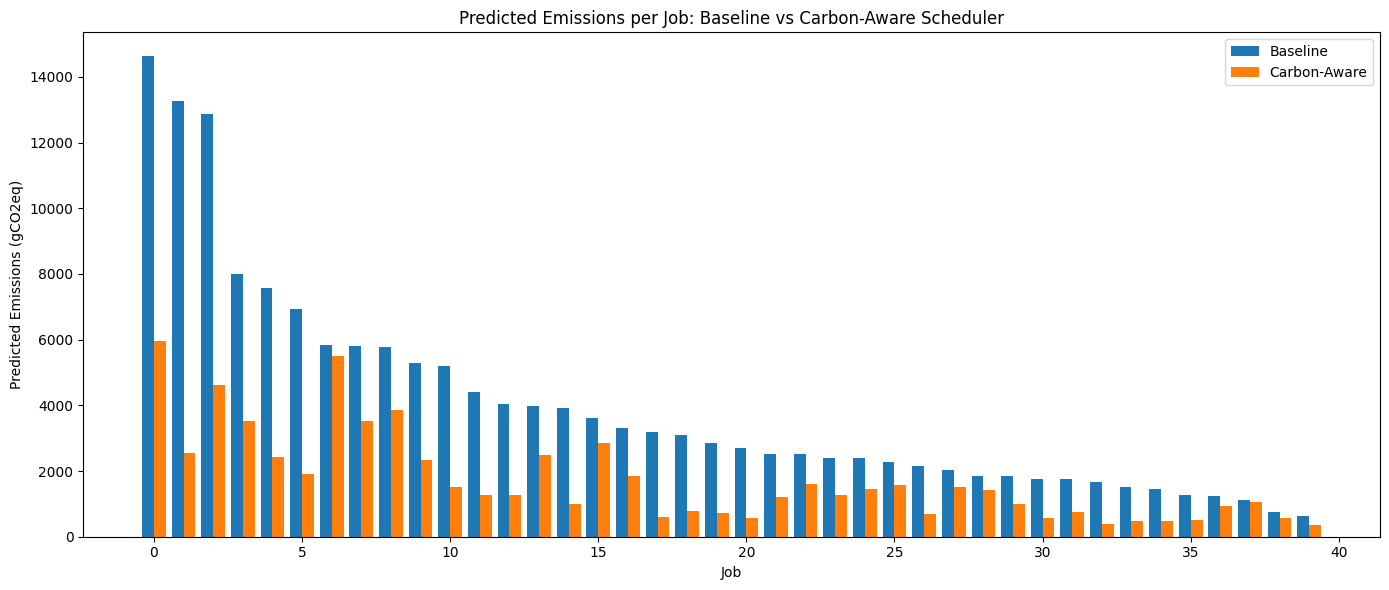

In [ ]:
# ============================================================
# Plot: baseline vs carbon-aware emissions by job
# ============================================================

plot_df = analysis_df.dropna(subset=["baseline_emissions_gco2", "carbon_emissions_gco2"]).copy()
plot_df = plot_df.sort_values("baseline_emissions_gco2", ascending=False)

x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, plot_df["baseline_emissions_gco2"], width=width, label="Baseline")
plt.bar(x + width/2, plot_df["carbon_emissions_gco2"], width=width, label="Carbon-Aware")

plt.title("Predicted Emissions per Job: Baseline vs Carbon-Aware Scheduler")
plt.xlabel("Job")
plt.ylabel("Predicted Emissions (gCO2eq)")
plt.legend()
plt.tight_layout()
plt.show()

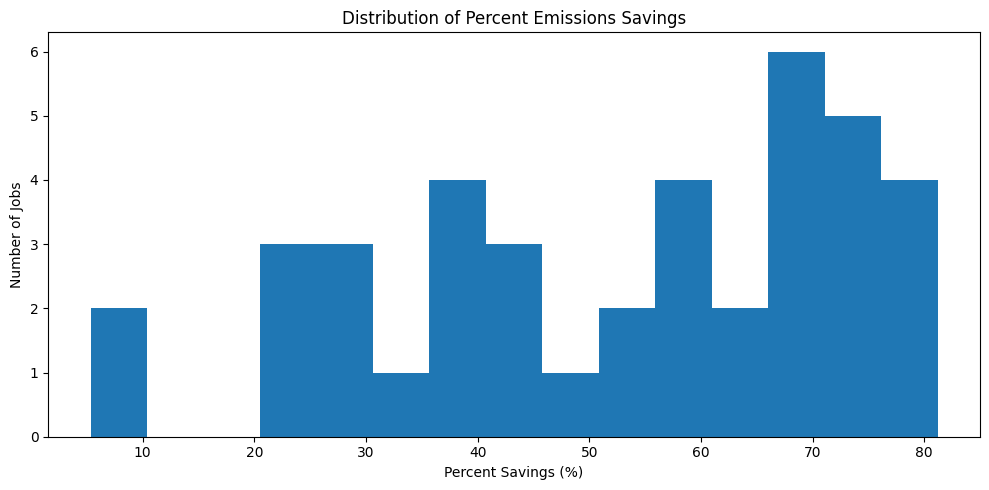

In [ ]:
# ============================================================
# Plot: distribution of percent savings
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(plot_df["percent_savings"].dropna(), bins=15)
plt.title("Distribution of Percent Emissions Savings")
plt.xlabel("Percent Savings (%)")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

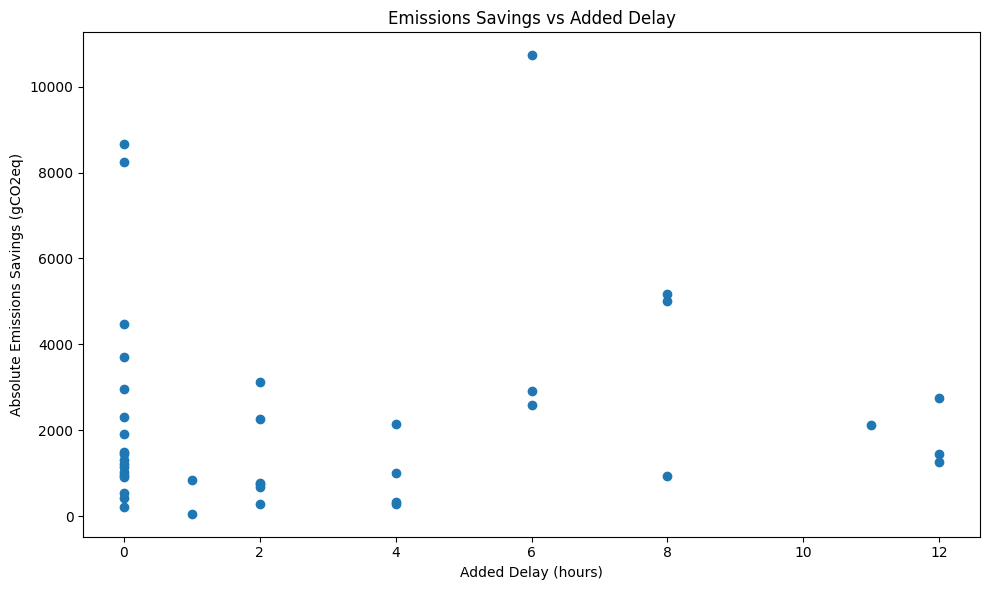

In [ ]:
# ============================================================
# Plot: savings vs delay
# ============================================================

scatter_df = analysis_df.dropna(subset=["absolute_savings_gco2", "extra_delay_hours"]).copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["extra_delay_hours"], scatter_df["absolute_savings_gco2"])
plt.title("Emissions Savings vs Added Delay")
plt.xlabel("Added Delay (hours)")
plt.ylabel("Absolute Emissions Savings (gCO2eq)")
plt.tight_layout()
plt.show()

### Key Insights from Emissions Savings vs. Added Delay

- **Significant savings achievable with zero delay**
  - Many points at 0 hours delay still show meaningful emissions reductions
  - Scheduler can often improve outcomes *without impacting latency*

- **Weak correlation between delay and savings**
  - Higher delay does not consistently lead to higher savings
  - More delay ≠ better outcome; timing opportunities are uneven

- **High-variance savings at low delays**
  - At 0-2 hours, savings range from near zero to very high (~8000+ gCO₂eq)
  - Small flexibility can unlock large benefits in the right conditions

- **Diminishing returns at higher delays**
  - Beyond ~6-8 hours, savings do not consistently increase
  - → Long delays may not justify marginal additional gains

- **Outliers with very high savings**
  - A few points show extremely large reductions (~10,000+ gCO₂eq)
  - → Indicates rare but valuable optimal scheduling windows

- **Clusters of moderate savings (~1000-3000 gCO₂eq)**
  - Most points fall in this range across different delays
  - → Typical achievable benefit level for most jobs

- **Some cases with minimal or no savings**
  - Points near zero savings even with added delay
  - → Not all jobs benefit from rescheduling

- **Opportunity exists in short-delay region (0-4 hours)**
  - Many strong savings outcomes occur with minimal delay
  - → Ideal tradeoff zone for practical scheduling systems

- **Overall takeaway**
  - Carbon-aware scheduling can deliver meaningful emissions reductions with little to no delay, but benefits are highly context-dependent rather than strictly increasing with wait time

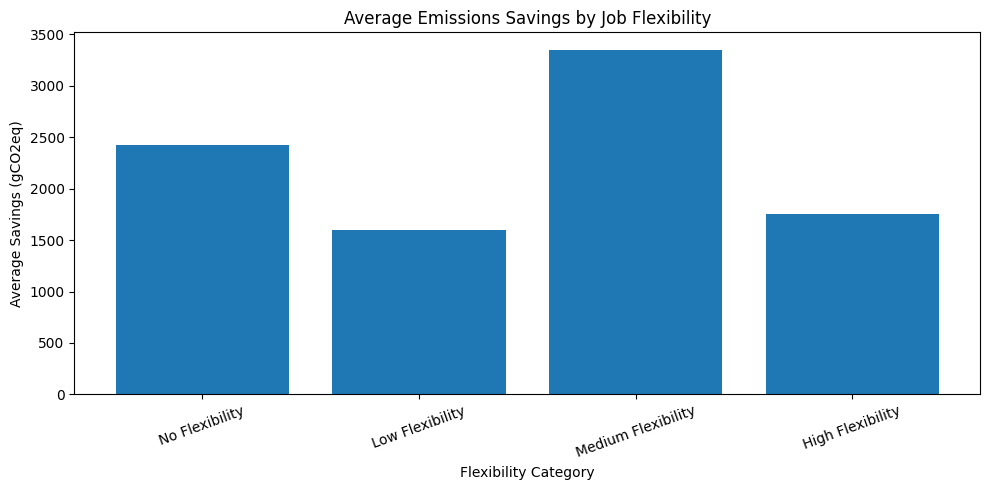

In [ ]:
# ============================================================
# Plot: average savings by flexibility category
# ============================================================

flex_df = analysis_df.dropna(subset=["absolute_savings_gco2", "job_flexibility"]).copy()
flex_summary = flex_df.groupby("job_flexibility", observed=False)["absolute_savings_gco2"].mean()

plt.figure(figsize=(10, 5))
plt.bar(flex_summary.index.astype(str), flex_summary.values)
plt.title("Average Emissions Savings by Job Flexibility")
plt.xlabel("Flexibility Category")
plt.ylabel("Average Savings (gCO2eq)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Key Insights from Average Emissions Savings by Job Flexibility

- **Medium flexibility yields the highest average savings**
  - Clearly outperforms all other categories (~3300+ gCO₂eq)
  - Moderate scheduling flexibility is the most effective sweet spot

- **No flexibility still achieves substantial savings**
  - Surprisingly high (~2400+ gCO₂eq), second only to medium
  - Many optimization opportunities exist *without any delay*

- **High flexibility does not guarantee higher savings**
  - Lower than both medium and no flexibility
  - More flexibility ≠ better outcomes; depends on alignment with low-carbon windows

- **Low flexibility performs the worst**
  - Lowest average savings (~1600 gCO₂eq)
  - Small delays may be insufficient to reach optimal windows

- **Non-linear relationship between flexibility and savings**
  - Savings do not increase monotonically with flexibility
  - Timing opportunities are uneven and context-dependent

- **Evidence of “optimal window alignment” effect**
  - Medium flexibility likely aligns best with common low-carbon periods
  - Too little or too much flexibility can miss ideal timing windows

- **Diminishing returns at higher flexibility levels**
  - High flexibility doesn’t significantly outperform lower categories
  - Additional waiting time may not translate into better carbon outcomes

- **Key insight: timing > flexibility**
  - The *specific window* a job can access matters more than how long it can wait
  - Scheduler effectiveness depends on intelligently selecting windows, not just delaying jobs

- **Overall takeaway**
  - Carbon savings are driven by alignment with low-carbon periods, not simply by increasing flexibility—highlighting the importance of intelligent scheduling over brute-force delay

In [ ]:
# How often did the scheduler delay jobs?
delay_rate = (analysis_df["extra_delay_hours"] > 0).mean() * 100
print(f"Percentage of jobs delayed by the carbon-aware scheduler: {delay_rate:.2f}%")

Percentage of jobs delayed by the carbon-aware scheduler: 55.00%


In [ ]:
# How often did it move jobs to another region?
region_change_rate = analysis_df["changed_region"].mean() * 100
print(f"Percentage of jobs moved to a different region: {region_change_rate:.2f}%")

Percentage of jobs moved to a different region: 82.50%


In [ ]:
# Which regions were chosen most often by the carbon-aware scheduler?
analysis_df["carbon_region"].value_counts(dropna=False)

,count
carbon_region,
CAISO,40


## 5. Model-Based Scheduler Experiments

Repeat the same scheduling experiments using our ML-generated forecasts to evaluate how forecast quality impacts scheduling performance

In [ ]:
# =====================================================
# Example job for model-generated forecast scheduling
# =====================================================

job_forecast_test = MLJob(
    job_id="job_forecast_001",
    submission_time=carbon_forecast_df["datetime"].min(),
    deadline=carbon_forecast_df["datetime"].min() + pd.Timedelta(hours=18),
    max_delay_hours=8,
    runtime_hours=4,
    total_energy_kwh=12.0,
    default_region="NYISO",
    allowed_regions=["NYISO", "CAISO", "ERCOT", "MISO", "ISONE"]
)

print(job_forecast_test)

MLJob(job_id='job_forecast_001', submission_time=Timestamp('2026-04-20 00:00:00+0000', tz='UTC'), deadline=Timestamp('2026-04-20 18:00:00+0000', tz='UTC'), max_delay_hours=8, runtime_hours=4, total_energy_kwh=12.0, default_region='NYISO', allowed_regions=['NYISO', 'CAISO', 'ERCOT', 'MISO', 'ISONE'])


### 5.1 Single Job Evaluation (Model Forecasts)

test how scheduling decisions differ when using our predicted carbon intensity instead of API forecasts

In [ ]:
# run baseline and carbon-aware scheduling with model forecasts

baseline_result = baseline_schedule(job_forecast_test, carbon_forecast_df)
schedule_result = carbon_aware_schedule(job_forecast_test, carbon_forecast_df)

best_schedule = schedule_result["best_schedule"]
candidates_df = schedule_result["candidates_df"]

comparison = compare_schedulers(baseline_result, best_schedule)

display_schedule_result("Baseline Schedule (Model Forecasts)", baseline_result)
display_schedule_result("Carbon-Aware Best Schedule (Model Forecasts)", best_schedule)
display_schedule_result("Comparison Summary (Model Forecasts)", comparison)

Baseline Schedule (Model Forecasts)
job_id: job_forecast_001
region_name: NYISO
start_time: 2026-04-20 00:00:00+00:00
finish_time: 2026-04-20 04:00:00+00:00
delay_hours: 0
runtime_hours: 4
total_energy_kwh: 12.0
predicted_emissions_gco2: 3690.6326682737254

Carbon-Aware Best Schedule (Model Forecasts)
job_id: job_forecast_001
region_name: CAISO
start_time: 2026-04-20 00:00:00+00:00
finish_time: 2026-04-20 04:00:00+00:00
delay_hours: 0
runtime_hours: 4
total_energy_kwh: 12.0
predicted_emissions_gco2: 1570.6363765128904

Comparison Summary (Model Forecasts)
baseline_emissions_gco2: 3690.6326682737254
carbon_aware_emissions_gco2: 1570.6363765128904
absolute_savings_gco2: 2119.996291760835
percent_savings: 57.44262521668006
added_delay_hours: 0
baseline_region: NYISO
carbon_aware_region: CAISO
baseline_start_time: 2026-04-20 00:00:00+00:00
carbon_aware_start_time: 2026-04-20 00:00:00+00:00



### 5.2 Batch Simulation (Model Forecasts)

run large-scale simulations to evaluate:
- emissions savings
- delay tradeoffs
- robustness to forecast error

In [ ]:
# rerun batch experiment using model-generated forecasts

# ============================================================
# Generate jobs that fit inside the forecast horizon
# ============================================================

forecast_window_start = carbon_forecast_df["datetime"].min()
forecast_window_end = carbon_forecast_df["datetime"].max()

jobs_model_forecast = generate_synthetic_jobs(
    n_jobs=30,
    submission_start=forecast_window_start,
    submission_end=forecast_window_start + pd.Timedelta(hours=8),
    region_names=["NYISO", "CAISO", "ERCOT", "MISO", "ISONE"],
    seed=42
)

# filter to jobs that are actually feasible within forecast horizon
filtered_jobs = []
for job in jobs_model_forecast:
    latest_finish = job.submission_time + pd.Timedelta(hours=job.max_delay_hours + job.runtime_hours)
    if latest_finish <= forecast_window_end:
        filtered_jobs.append(job)

print("Original jobs:", len(jobs_model_forecast))
print("Jobs within forecast horizon:", len(filtered_jobs))

Original jobs: 30
Jobs within forecast horizon: 29


In [ ]:
# run experiment
results_df = run_scheduler_experiment(filtered_jobs, carbon_forecast_df)
analysis_df = results_df.copy()

analysis_df["savings_per_delay_hour"] = analysis_df["absolute_savings_gco2"] / analysis_df["extra_delay_hours"]
analysis_df["savings_per_delay_hour"] = analysis_df["savings_per_delay_hour"].replace([np.inf, -np.inf], np.nan)

analysis_df["job_flexibility"] = pd.cut(
    analysis_df["max_delay_hours"],
    bins=[-1, 0, 4, 8, 24],
    labels=["No Flexibility", "Low Flexibility", "Medium Flexibility", "High Flexibility"]
)

analysis_df["job_runtime_bucket"] = pd.cut(
    analysis_df["runtime_hours"],
    bins=[0, 2, 4, 6, 12],
    labels=["Short", "Medium", "Long", "Very Long"]
)

summary = summarize_experiment(results_df)

print("Experiment Summary Using Model-Generated Forecasts")
print("=" * 60)
for key, value in summary.items():
    print(f"{key}: {value}")

Experiment Summary Using Model-Generated Forecasts
num_jobs_evaluated: 29
total_baseline_emissions_gco2: 134606.05137791033
total_carbon_aware_emissions_gco2: 70444.17742732896
total_absolute_savings_gco2: 64161.87395058139
average_percent_savings: 40.98386206753918
average_extra_delay_hours: 1.8620689655172413
median_extra_delay_hours: 0.0
jobs_with_region_change_pct: 79.3103448275862
jobs_with_start_change_pct: 27.586206896551722


In [ ]:
# Model forecast experiment summary
summary = summarize_experiment(results_df)

if summary is None:
    print("No valid model-forecast experiment results to summarize.")
else:
    print("Model Forecast Experiment Summary")
    print("=" * 50)
    for key, value in summary.items():
        print(f"{key}: {value}")


Model Forecast Experiment Summary
num_jobs_evaluated: 29
total_baseline_emissions_gco2: 134606.05137791033
total_carbon_aware_emissions_gco2: 70444.17742732896
total_absolute_savings_gco2: 64161.87395058139
average_percent_savings: 40.98386206753918
average_extra_delay_hours: 1.8620689655172413
median_extra_delay_hours: 0.0
jobs_with_region_change_pct: 79.3103448275862
jobs_with_start_change_pct: 27.586206896551722


### 5.3 Results and Analysis (Model Forecasts)
analyze scheduling performance under model-generated forecasts and compare trends with API-based results.

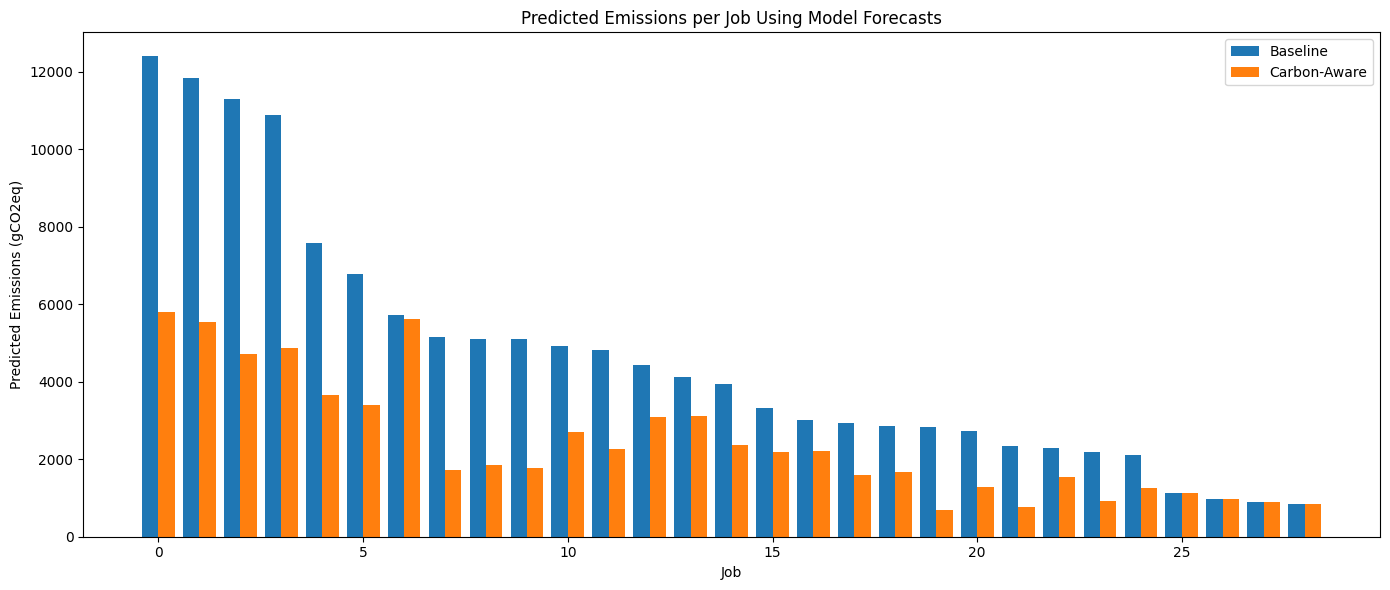

In [ ]:
# model forecast plots
# Baseline vs carbon-aware emissions
plot_df = analysis_df.dropna(subset=["baseline_emissions_gco2", "carbon_emissions_gco2"]).copy()
plot_df = plot_df.sort_values("baseline_emissions_gco2", ascending=False)

x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, plot_df["baseline_emissions_gco2"], width=width, label="Baseline")
plt.bar(x + width/2, plot_df["carbon_emissions_gco2"], width=width, label="Carbon-Aware")

plt.title("Predicted Emissions per Job Using Model Forecasts")
plt.xlabel("Job")
plt.ylabel("Predicted Emissions (gCO2eq)")
plt.legend()
plt.tight_layout()
plt.show()

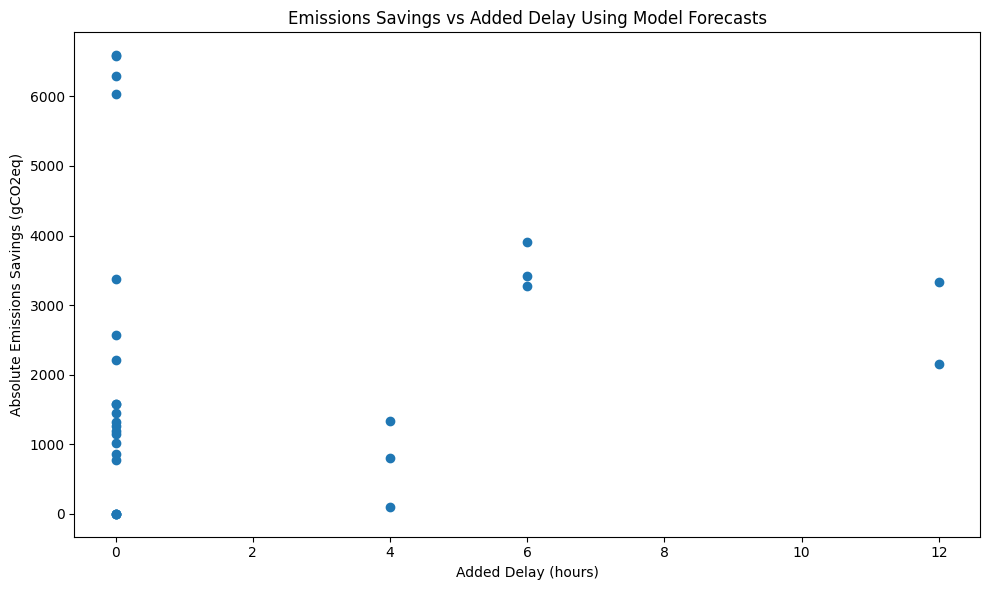

In [ ]:
# Savings vs delay
scatter_df = analysis_df.dropna(subset=["absolute_savings_gco2", "extra_delay_hours"]).copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["extra_delay_hours"], scatter_df["absolute_savings_gco2"])
plt.title("Emissions Savings vs Added Delay Using Model Forecasts")
plt.xlabel("Added Delay (hours)")
plt.ylabel("Absolute Emissions Savings (gCO2eq)")
plt.tight_layout()
plt.show()

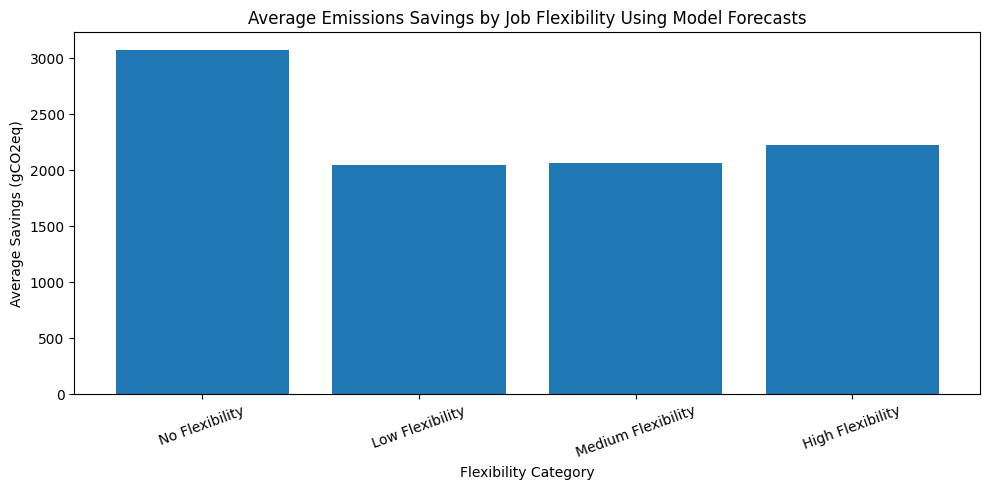

In [ ]:
# Savings by flexibility
flex_df = analysis_df.dropna(subset=["absolute_savings_gco2", "job_flexibility"]).copy()
flex_summary = flex_df.groupby("job_flexibility", observed=False)["absolute_savings_gco2"].mean()

plt.figure(figsize=(10, 5))
plt.bar(flex_summary.index.astype(str), flex_summary.values)
plt.title("Average Emissions Savings by Job Flexibility Using Model Forecasts")
plt.xlabel("Flexibility Category")
plt.ylabel("Average Savings (gCO2eq)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()